# Matemática IV

# Trabajo Práctico Final: Ciencia de Datos

## Análisis de Datos del Transporte Aéreo en Argentina

**Integrantes:**  
- Baselli María  
- Fernández Emiliano  
- Letelle Mauro

# Índice
- Introducción
- Fuentes de datos
- Objetivos del análisis
- Metodología y preparación de datos
- **Análisis general del mercado aerocomercial argentino**
    - Demanda por hora, día y mes
    - Rutas y niveles de ocupación
    - Valores atípicos y evolución histórica
    - Análisis de demoras
    - Modelos binomial y Poisson
    -  Conclusiones de la Parte I
- **Análisis específico de San Carlos de Bariloche**
    -  Contexto y objetivos del caso Bariloche
    -  Estadística descriptiva
    -  Demanda mensual, horaria y semanal
    -  Modelos binomial y Poisson
    -  Modelo predictivo y feriados largos
    -  Recomendaciones
    -  Conclusiones del caso Bariloche
-  **Cierre**
    -  Conclusiones generales
    -  Limitaciones generales
-  Bibliografía


# PARTE I: Análisis general del mercado aércomercial

# Introducción

El transporte aéreo cumple un rol central en la conectividad de Argentina: reduce distancias, integra regiones, sostiene actividad turística y económica, y permite observar patrones de movilidad que no siempre son visibles en otros medios de transporte. Analizar sus datos permite responder preguntas concretas sobre demanda, ocupación, rutas relevantes y puntualidad del servicio.

Este trabajo estudia el comportamiento reciente del mercado aerocomercial argentino a partir de tres fuentes locales: conectividad aérea, movimientos aeroportuarios de ANAC e información de demoras publicada por Failbondi. El objetivo no es solo describir los datos, sino transformar esos resultados en conclusiones útiles para tomar decisiones operativas: dónde hay mayor demanda, cuándo se concentran los pasajeros, qué rutas sostienen más tráfico, qué servicios tienen alta ocupación y dónde aparecen más demoras.

Todo el análisis se ejecuta localmente desde este repositorio. Los archivos crudos se encuentran en `datasets/` y el material de limpieza previo queda como referencia en `Datasets ANALIZADOS/`.

# Fuente de datos

El notebook utiliza tres conjuntos de datos locales:

1. **Conectividad aérea**  
   Archivos: `conectividad_aerea_cabotaje.csv` y `conectividad_aerea_internacional.csv`.  
   Contienen vuelos, pasajeros, asientos, aerolíneas, rutas, origen, destino, clase de vuelo y fecha. En los archivos disponibles cubren el período **2019-2026**.

2. **Aterrizajes y despegues ANAC**  
   Archivos: `202512-informe-ministerio-actualizado-dic-final.csv` y `202604-informe-ministerio.csv`.  
   Contienen movimientos aeroportuarios, `Pasajeros`, `PAX`, fecha, hora, aeropuerto, aerolínea, tipo de movimiento y clasificación del vuelo. En ANAC, `Pasajeros` y `PAX` no son equivalentes: `Pasajeros` mide personas por movimiento aeroportuario y `PAX` se usa como pasajeros equivalentes para demanda agregada. Con los CSV locales actuales cubren **2025-2026**. Para análisis por hora, día y mes se usa **2025 completo**, porque 2026 está incompleto.

3. **Failbondi**  
   Archivo: `failbondi-2026-05-20-dump.json`.  
   Contiene vuelos, aerolínea, aeropuerto, movimiento, estado, matrícula, aeronave, fecha programada y diferencia temporal respecto de la operación prevista. Como el dump fue generado el **20/05/2026**, se recortan vuelos posteriores a esa fecha para no analizar vuelos futuros como si fueran observados.

Fuentes mencionadas:

- Tableros Yvera: https://tableros.yvera.tur.ar/conectividad/
- Datos abiertos ANAC: https://www.datos.gob.ar/
- Failbondi: https://failbondi.fail/acerca

## Objetivo general

Analizar datos del transporte aéreo argentino para identificar patrones de demanda, ocupación y demoras que ayuden a comprender el funcionamiento del sistema y a proponer decisiones operativas basadas en datos.

## Preguntas de análisis

1. ¿Cuál es el volumen y alcance temporal real de cada fuente?
2. ¿En qué horarios se concentra la mayor y menor demanda de pasajeros equivalentes?
3. ¿Qué días de la semana tienen más movimiento?
4. ¿Qué meses presentan mayor y menor cantidad de pasajeros equivalentes?
5. ¿Qué rutas concentran más pasajeros en cabotaje, internacional y total?
6. ¿Cómo se comporta la ocupación y qué criterio se usa para definir alta ocupación?
7. ¿Qué valores atípicos aparecen en la serie histórica y cómo se interpretan?
8. ¿Cuál es el comportamiento general de las demoras?
9. ¿Las demoras cambian según tipo de movimiento y aerolínea?
10. ¿Las demoras varían según hora del día y día de semana?
11. ¿Qué probabilidades pueden estimarse con modelos binomial y Poisson?

# Metodología y decisiones de limpieza

- El análisis usa rutas locales del repositorio y no depende de servicios externos.
- Para ANAC se usa 2025 completo en gráficos por hora, día y mes. Los datos de 2026 se mantienen para inspección, pero no para comparar años completos.
- En ANAC `Pasajeros` y `PAX` no son lo mismo. `Pasajeros` cuenta personas asociadas a cada movimiento aeroportuario (`Aterrizaje` o `Despegue`). `PAX` se usa como pasajeros equivalentes para demanda agregada: coincide con `Pasajeros` en vuelos internacionales, pero en vuelos domésticos suele ser aproximadamente la mitad para evitar duplicar cabotaje al sumar demanda.
- Failbondi se recorta hasta el 20/05/2026, fecha del dump local, para evitar vuelos futuros programados.
- Se considera demora relevante cuando `delta_minutos > 15`.
- Para limpiar demoras extremas se conservan vuelos entre `-180` y `360` minutos. El recorte evita que valores aislados dominen promedios y gráficos.
- La ocupación se calcula como `Pasajeros / Asientos`, porque mide qué proporción de asientos se ocupó en el movimiento registrado.
- Los nulos de ocupación no se pisan: se conserva `ocupacion_original`, se marca `ocupacion_fue_imputada` y se crea `ocupacion` imputada con la media de su clasificación.
- La alta ocupación no usa un umbral arbitrario. Se define por clasificación: un registro tiene alta ocupación si su ocupación es mayor o igual a la mediana de su grupo (`Cabotaje` o `Internacional`).

# Carga de librerías y rutas locales

In [32]:
from pathlib import Path  
from math import comb, exp, factorial  
import json
from scipy.stats import poisson, norm
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

try:
    from IPython.display import display
except ImportError:
    display = print

Path('.matplotlib').mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib'))


pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)
plt.style.use('seaborn-v0_8-whitegrid')

ARCHIVOS_REQUERIDOS = [
    'conectividad_aerea_cabotaje.csv',
    'conectividad_aerea_internacional.csv',
    '202312-informe-ministerio-actualizado-dic.csv',
    '202412-informe-ministerio-actualizado-dic-final.csv',
    '202512-informe-ministerio-actualizado-dic-final.csv',
    '202604-informe-ministerio.csv',
    'failbondi-2026-05-20-dump.json',
]

def resolver_base_dir():
    actual = Path.cwd().resolve()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / 'datasets').is_dir():
            return carpeta
    raise FileNotFoundError(
        'No se encontró la carpeta datasets/. Abrí VS Code en la raíz del proyecto MateIV_Transporte_Publico.'
    )

BASE_DIR = resolver_base_dir()
DATA_DIR = BASE_DIR / 'datasets'
ANALIZADOS_DIR = BASE_DIR / 'Datasets ANALIZADOS'

faltantes = [archivo for archivo in ARCHIVOS_REQUERIDOS if not (DATA_DIR / archivo).is_file()]
if faltantes:
    mensaje = 'Faltan archivos en datasets/:' + chr(10) + '- ' + (chr(10) + '- ').join(faltantes)
    raise FileNotFoundError(mensaje)

print('Carpeta base:', BASE_DIR)
print('Carpeta datasets:', DATA_DIR)
print('Carpeta datasets analizados:', ANALIZADOS_DIR)
print('Archivos encontrados:')
for archivo in sorted(p.name for p in DATA_DIR.iterdir() if p.is_file()):
    print('-', archivo)

Carpeta base: /home/mauro/git/MateIV_Transporte_Publico
Carpeta datasets: /home/mauro/git/MateIV_Transporte_Publico/datasets
Carpeta datasets analizados: /home/mauro/git/MateIV_Transporte_Publico/Datasets ANALIZADOS
Archivos encontrados:
- 202312-informe-ministerio-actualizado-dic.csv
- 202412-informe-ministerio-actualizado-dic-final.csv
- 202512-informe-ministerio-actualizado-dic-final.csv
- 202604-informe-ministerio.csv
- conectividad_aerea_cabotaje.csv
- conectividad_aerea_internacional.csv
- failbondi-2026-05-20-dump.json


# Carga y preparación de datos

In [33]:
MESES = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4,
    'Mayo': 5,
    'Junio': 6,
    'Julio': 7,
    'Agosto': 8,
    'Septiembre': 9,
    'Octubre': 10,
    'Noviembre': 11,
    'Diciembre': 12,
}

DIAS = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo',
}

ORDEN_DIAS = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
FECHA_CORTE_FAILBONDI = pd.Timestamp('2026-05-20 23:59:59', tz='UTC')


def leer_conectividad(nombre_archivo, clasificacion):
    df = pd.read_csv(DATA_DIR / nombre_archivo)
    df.columns = df.columns.str.strip()
    df['Clasificacion'] = clasificacion
    df['mes_num'] = df['Mes'].map(MESES)
    df['fecha'] = pd.to_datetime(
        dict(year=df['Año'], month=df['mes_num'], day=df['Dia']),
        errors='coerce'
    )
    df['anio'] = df['fecha'].dt.year
    df['ocupacion_original'] = np.where(df['Asientos'] > 0, df['Pasajeros'] / df['Asientos'], np.nan)
    return df


def leer_anac(nombre_archivo):
    df = pd.read_csv(DATA_DIR / nombre_archivo, sep=';', decimal=',', on_bad_lines='warn')
    df.columns = df.columns.str.strip()

    for columna in ['Pasajeros', 'PAX']:
        df[columna] = pd.to_numeric(df[columna], errors='coerce')

    df['pasajeros_movimiento'] = df['Pasajeros']
    df['pasajeros_equivalentes'] = df['PAX']

    df['Fecha UTC'] = pd.to_datetime(df['Fecha UTC'], dayfirst=True, errors='coerce')
    df['anio'] = df['Fecha UTC'].dt.year
    df['mes'] = df['Fecha UTC'].dt.month
    df['dia_semana'] = df['Fecha UTC'].dt.day_name().map(DIAS)
    df['hora'] = pd.to_datetime(df['Hora UTC'], format='%H:%M', errors='coerce').dt.hour
    return df


def cargar_failbondi(path, chunk_size=1024 * 1024):
    registros = []
    decoder = json.JSONDecoder()
    buffer = ''
    dentro_array = False
    fin = False

    with open(path, encoding='utf-8', errors='replace') as archivo:
        while not fin:
            chunk = archivo.read(chunk_size)
            if chunk == '':
                fin = True
            buffer += chunk

            while True:
                buffer = buffer.lstrip()

                if not dentro_array:
                    if not buffer:
                        break
                    if buffer[0] != '[':
                        raise ValueError('El JSON de Failbondi no empieza con un array.')
                    buffer = buffer[1:]
                    dentro_array = True
                    buffer = buffer.lstrip()

                if buffer.startswith(']'):
                    fin = True
                    break

                if buffer.startswith(','):
                    buffer = buffer[1:].lstrip()

                if not buffer:
                    break

                try:
                    item, idx = decoder.raw_decode(buffer)
                except json.JSONDecodeError:
                    break

                raw = item.get('json') or {}
                registros.append({
                    'flight_id': item.get('aerolineas_flight_id'),
                    'fecha_programada': item.get('stda_parsed'),
                    'aeropuerto': raw.get('arpt'),
                    'movimiento': raw.get('mov'),
                    'nro_vuelo': raw.get('nro'),
                    'aerolinea': raw.get('aerolinea'),
                    'destino_origen': raw.get('destorig'),
                    'estado': raw.get('estes'),
                    'matricula': item.get('matricula'),
                    'aeronave': item.get('aeronave'),
                    'edad_avion': item.get('edad_del_avion'),
                    'delta_segundos': item.get('delta'),
                })
                buffer = buffer[idx:]

    df = pd.DataFrame(registros)
    df['fecha_programada'] = pd.to_datetime(df['fecha_programada'], errors='coerce')
    df['delta_segundos'] = pd.to_numeric(df['delta_segundos'], errors='coerce')
    df['delta_minutos'] = df['delta_segundos'] / 60
    df['demorado_15m'] = df['delta_minutos'] > 15
    df['adelantado_5m'] = df['delta_minutos'] < -5
    df['fecha'] = df['fecha_programada'].dt.date
    df['hora'] = df['fecha_programada'].dt.hour
    df['dia_semana'] = df['fecha_programada'].dt.day_name().map(DIAS)
    df['tipo_movimiento'] = df['movimiento'].map({'A': 'Arribo', 'D': 'Partida'}).fillna(df['movimiento'])
    return df

conectividad = pd.concat([
    leer_conectividad('conectividad_aerea_cabotaje.csv', 'Cabotaje'),
    leer_conectividad('conectividad_aerea_internacional.csv', 'Internacional'),
], ignore_index=True)

media_ocupacion_por_clase = conectividad.groupby('Clasificacion')['ocupacion_original'].transform('mean')
conectividad['ocupacion_fue_imputada'] = conectividad['ocupacion_original'].isna()
conectividad['ocupacion'] = conectividad['ocupacion_original'].fillna(media_ocupacion_por_clase)

umbral_alta_ocupacion = conectividad.groupby('Clasificacion')['ocupacion'].median()
conectividad['umbral_alta_ocupacion'] = conectividad['Clasificacion'].map(umbral_alta_ocupacion)
conectividad['alta_ocupacion'] = conectividad['ocupacion'] >= conectividad['umbral_alta_ocupacion']

anac = pd.concat([
    leer_anac('202312-informe-ministerio-actualizado-dic.csv'),
    leer_anac('202412-informe-ministerio-actualizado-dic-final.csv'),
    leer_anac('202512-informe-ministerio-actualizado-dic-final.csv'),
    leer_anac('202604-informe-ministerio.csv'),
], ignore_index=True)
anac_2025 = anac[anac['anio'] == 2025].copy()

failbondi_raw = cargar_failbondi(DATA_DIR / 'failbondi-2026-05-20-dump.json')
failbondi = failbondi_raw[failbondi_raw['fecha_programada'] <= FECHA_CORTE_FAILBONDI].copy()
failbondi_limpio = failbondi[failbondi['delta_minutos'].between(-180, 360)].copy()

print('Datos cargados y preparados.')

Datos cargados y preparados.


## Diferencia entre Pasajeros y PAX en ANAC
No son lo mismo en este dataset.
Pasajeros: Cuenta pasajeros asociados a un Aterrizaje o a un Despegue. Es una variable de operación/movimiento. 
PAX: En vuelos internacionales coincide con Pasajeros. En vuelos domésticos suele ser aproximadamente la mitad de Pasajeros, porque el sistema puede registrar el viaje dentro del país en dos movimientos nacionales: salida y llegada. 
Ejemplo real del archivo ANAC: si un movimiento doméstico tiene Pasajeros = 167, aparece PAX = 83.5. En internacional, si Pasajeros = 281, aparece PAX = 281.
Por eso no se mezclan como sinónimos:
- Para **demanda agregada** se usa PAX / pasajeros_equivalentes.
- Para **pasajeros asociados a un movimiento** se usa Pasajeros / pasajeros_movimiento.
- Para **ocupación** se usa Pasajeros / Asientos, porque la ocupación corresponde al movimiento registrado.


In [34]:
comparacion_pax = anac.groupby('Clasificación Vuelo').agg(
    pasajeros_movimiento=('pasajeros_movimiento', 'sum'),
    pasajeros_equivalentes=('pasajeros_equivalentes', 'sum'),
).reset_index()
comparacion_pax['relacion_pasajeros_sobre_pax'] = (
    comparacion_pax['pasajeros_movimiento'] / comparacion_pax['pasajeros_equivalentes']
)

muestra_pax = anac[[
    'Fecha UTC',
    'Tipo de Movimiento',
    'Clasificación Vuelo',
    'pasajeros_movimiento',
    'pasajeros_equivalentes',
]].head(8)

print('Comparación acumulada por clasificación')
display(comparacion_pax)

print('Ejemplos de registros reales')
display(muestra_pax)

print(
    'Conclusión: en ANAC, Pasajeros y PAX no son sinónimos. '
    'En internacional coinciden, pero en doméstico Pasajeros es casi el doble de PAX. '
    'Por eso el análisis de demanda agregada usa PAX como pasajeros_equivalentes, '
    'mientras que Pasajeros queda como pasajeros_movimiento.'
)


Comparación acumulada por clasificación


,Clasificación Vuelo,pasajeros_movimiento,pasajeros_equivalentes,relacion_pasajeros_sobre_pax
0,Doméstico,113009673.0,56526987.0,1.999216
1,Internacional,47836075.0,47836075.0,1.000000


Ejemplos de registros reales


,Fecha UTC,Tipo de Movimiento,Clasificación Vuelo,pasajeros_movimiento,pasajeros_equivalentes
0,2023-01-01,Aterrizaje,Internacional,199.0,199.0
1,2023-01-01,Despegue,Doméstico,67.0,33.5
2,2023-01-01,Aterrizaje,Internacional,36.0,36.0
3,2023-01-01,Aterrizaje,Doméstico,168.0,84.0
4,2023-01-01,Aterrizaje,Doméstico,17.0,8.5
5,2023-01-01,Aterrizaje,Internacional,171.0,171.0
6,2023-01-01,Aterrizaje,Internacional,83.0,83.0
7,2023-01-01,Aterrizaje,Doméstico,187.0,93.5


Conclusión: en ANAC, Pasajeros y PAX no son sinónimos. En internacional coinciden, pero en doméstico Pasajeros es casi el doble de PAX. Por eso el análisis de demanda agregada usa PAX como pasajeros_equivalentes, mientras que Pasajeros queda como pasajeros_movimiento.


# ¿Cuál es el volumen y alcance temporal real de cada fuente?

In [35]:
resumen_datasets = pd.DataFrame([
    {
        'fuente': 'Conectividad',
        'filas': len(conectividad),
        'columnas': conectividad.shape[1],
        'fecha_inicio': conectividad['fecha'].min().date(),
        'fecha_fin': conectividad['fecha'].max().date(),
        'uso_en_analisis': 'Serie 2019-2026; para tendencias anuales se excluye 2026 parcial',
    },
    {
        'fuente': 'ANAC aterrizajes/despegues',
        'filas': len(anac),
        'columnas': anac.shape[1],
        'fecha_inicio': anac['Fecha UTC'].min().date(),
        'fecha_fin': anac['Fecha UTC'].max().date(),
        'uso_en_analisis': 'Se usa 2023-2025 completo para hora, día y mes',
    },
    {
        'fuente': 'Failbondi recortado al dump',
        'filas': len(failbondi),
        'columnas': failbondi.shape[1],
        'fecha_inicio': failbondi['fecha_programada'].min().date(),
        'fecha_fin': failbondi['fecha_programada'].max().date(),
        'uso_en_analisis': 'Se excluyen vuelos posteriores al 20/05/2026',
    },
    {
        'fuente': 'Failbondi limpio para demoras',
        'filas': len(failbondi_limpio),
        'columnas': failbondi_limpio.shape[1],
        'fecha_inicio': failbondi_limpio['fecha_programada'].min().date(),
        'fecha_fin': failbondi_limpio['fecha_programada'].max().date(),
        'uso_en_analisis': 'Se conservan demoras entre -180 y 360 minutos',
    },
])

display(resumen_datasets)

filas_futuras_failbondi = len(failbondi_raw) - len(failbondi)
porcentaje_conservado_demoras = len(failbondi_limpio) / len(failbondi) * 100

print(
    f"Conclusión: el análisis combina fuentes con distinto alcance temporal. "
    f"ANAC se analiza sobre 2023/2024/2025 completo y Failbondi se recorta al 20/05/2026; "
    f"se excluyeron {filas_futuras_failbondi:,} vuelos futuros del dump y se conservó "
    f"{porcentaje_conservado_demoras:.2f}% de los registros observados para demoras."
)

,fuente,filas,columnas,fecha_inicio,fecha_fin,uso_en_analisis
0,Conectividad,765333,29,2019-01-01,2026-04-30,Serie 2019-2026; para tendencias anuales se ex...
1,ANAC aterrizajes/despegues,1930858,18,2023-01-01,2026-04-30,"Se usa 2023-2025 completo para hora, día y mes"
2,Failbondi recortado al dump,358711,19,2024-01-01,2026-05-20,Se excluyen vuelos posteriores al 20/05/2026
3,Failbondi limpio para demoras,336687,19,2024-12-22,2026-05-20,Se conservan demoras entre -180 y 360 minutos


Conclusión: el análisis combina fuentes con distinto alcance temporal. ANAC se analiza sobre 2023/2024/2025 completo y Failbondi se recorta al 20/05/2026; se excluyeron 2 vuelos futuros del dump y se conservó 93.86% de los registros observados para demoras.


# ¿En qué horarios se concentra la mayor y menor demanda de pasajeros equivalentes?

## Datos promedio por hora correspondientes a los años 2023/2024/2025

,hora,pasajeros_equivalentes
0,0,1403924.875
1,1,1132565.125
2,2,972863.625
3,3,870781.125
4,4,529588.625
5,5,408298.125
6,6,453194.750
7,7,588538.000
8,8,720968.125
9,9,869237.375


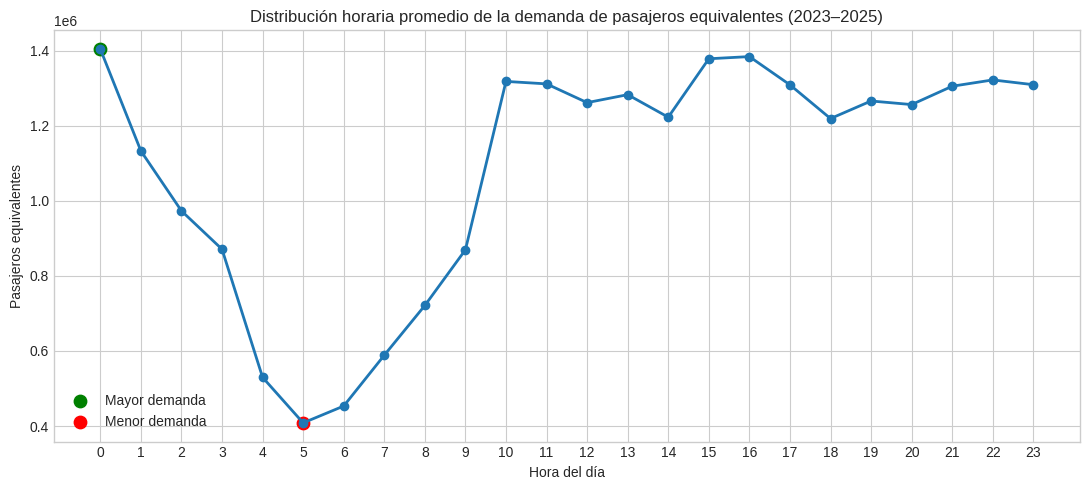

Conclusión: la mayor demanda se concentra a las 0:00 con 1,403,925 pasajeros equivalentes; la menor ocurre a las 5:00 con 408,298 pasajeros equivalentes. Esto sirve para identificar franjas donde reforzar capacidad operativa.


In [36]:
pax_por_hora = (
    anac.groupby(['anio', 'hora'])['pasajeros_equivalentes']
    .sum()
    .reset_index()
    .groupby('hora')['pasajeros_equivalentes']
    .mean()
    .reindex(range(24), fill_value=0)
    .reset_index()
)
pax_por_hora.columns = ['hora', 'pasajeros_equivalentes']

# Alias de compatibilidad: evita errores si quedó una ejecución vieja buscando PAX.
pax_por_hora['PAX'] = pax_por_hora['pasajeros_equivalentes']

hora_max = pax_por_hora.loc[pax_por_hora['pasajeros_equivalentes'].idxmax()]
hora_min = pax_por_hora.loc[pax_por_hora['pasajeros_equivalentes'].idxmin()]

display(pax_por_hora[['hora', 'pasajeros_equivalentes']])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pax_por_hora['hora'], pax_por_hora['pasajeros_equivalentes'], marker='o', linewidth=2)
ax.scatter([hora_max['hora']], [hora_max['pasajeros_equivalentes']], color='green', s=80, label='Mayor demanda')
ax.scatter([hora_min['hora']], [hora_min['pasajeros_equivalentes']], color='red', s=80, label='Menor demanda')
ax.set_title('Distribución horaria promedio de la demanda de pasajeros equivalentes (2023–2025)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Pasajeros equivalentes')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Conclusión: la mayor demanda se concentra a las {int(hora_max['hora'])}:00 "
    f"con {hora_max['pasajeros_equivalentes']:,.0f} pasajeros equivalentes; la menor ocurre a las {int(hora_min['hora'])}:00 "
    f"con {hora_min['pasajeros_equivalentes']:,.0f} pasajeros equivalentes. Esto sirve para identificar franjas donde reforzar capacidad operativa."
)


# ¿Qué días de la semana tienen más movimiento?

## Promedio de pasajeros equivalentes por día de la semana correspondiente a los años 2023/2025

,dia_semana,pasajeros_equivalentes
0,Lunes,3867923.125
1,Martes,3571455.125
2,Miércoles,3566322.250
3,Jueves,3672732.875
4,Viernes,3768415.000
5,Sábado,3897031.750
6,Domingo,3746885.375


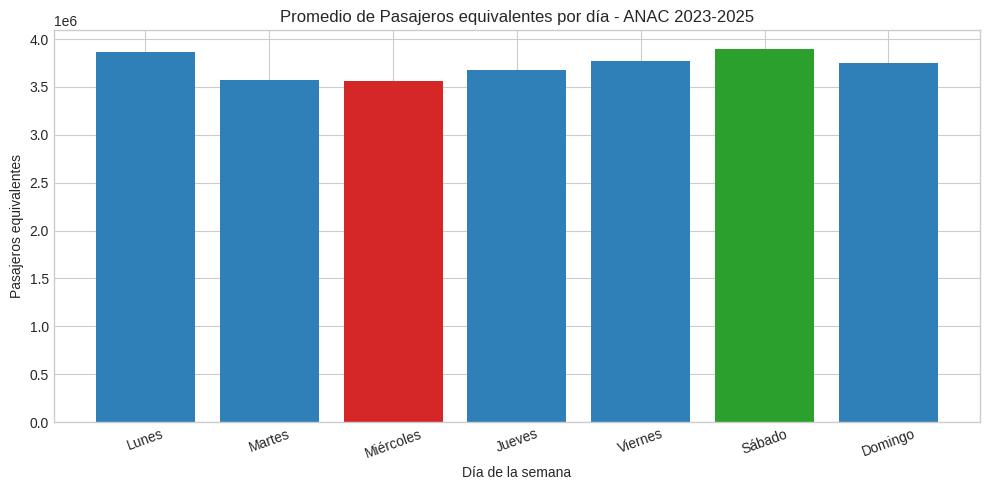

Conclusión: el día con más movimiento es Sábado (3,897,032 pasajeros equivalentes) y el menor es Miércoles (3,566,322 pasajeros equivalentes). La demanda semanal es relativamente pareja, pero el ranking ayuda a planificar recursos.


In [37]:
pax_por_dia = (
    anac.groupby(['anio', 'dia_semana'])['pasajeros_equivalentes']
    .sum()  # suma dentro de cada año
    .reset_index()
    .groupby('dia_semana')['pasajeros_equivalentes']
    .mean()  # promedio entre años
    .reindex(ORDEN_DIAS)  # mantener orden lunes->domingo
    .reset_index()
)

dia_max = pax_por_dia.loc[pax_por_dia['pasajeros_equivalentes'].idxmax()]
dia_min = pax_por_dia.loc[pax_por_dia['pasajeros_equivalentes'].idxmin()]

display(pax_por_dia)

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#2f7fb8' if dia not in [dia_max['dia_semana'], dia_min['dia_semana']] else '#2ca02c' if dia == dia_max['dia_semana'] else '#d62728' for dia in pax_por_dia['dia_semana']]
ax.bar(pax_por_dia['dia_semana'], pax_por_dia['pasajeros_equivalentes'], color=colores)
ax.set_title('Promedio de Pasajeros equivalentes por día - ANAC 2023-2025')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Pasajeros equivalentes')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(
    f"Conclusión: el día con más movimiento es {dia_max['dia_semana']} "
    f"({dia_max['pasajeros_equivalentes']:,.0f} pasajeros equivalentes) y el menor es {dia_min['dia_semana']} "
    f"({dia_min['pasajeros_equivalentes']:,.0f} pasajeros equivalentes). La demanda semanal es relativamente pareja, pero el ranking ayuda a planificar recursos."
)

# ¿Qué meses presentan mayor y menor cantidad de pasajeros equivalentes?

## Promedio de pasajeros equivalentes correspondiente al periodo 2023-2025

,mes,mes_nombre,pasajeros_equivalentes
0,1,Enero,2908572
1,2,Febrero,2610154
2,3,Marzo,2751669
3,4,Abril,2389134
4,5,Mayo,2252120
5,6,Junio,2240804
6,7,Julio,2716748
7,8,Agosto,2615551
8,9,Septiembre,2501168
9,10,Octubre,2636232


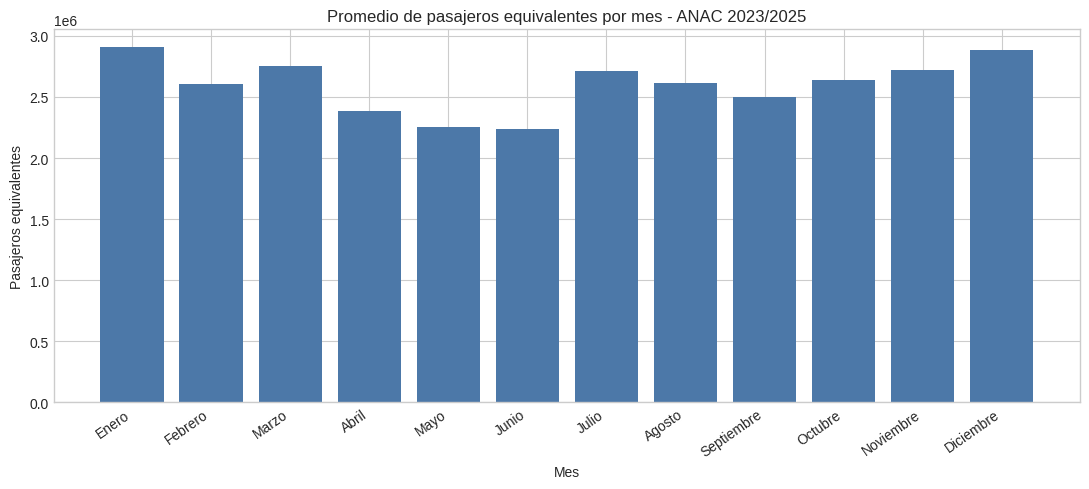

Conclusión: el mes con mayor movimiento fue Enero (2,908,572 pasajeros equivalentes) y el menor fue Junio (2,240,804 pasajeros equivalentes). Esta estacionalidad es útil para anticipar capacidad y demanda turística.


In [38]:
pax_por_mes = (
    anac.groupby(['anio', 'mes'])['pasajeros_equivalentes']
    .sum()  # total mensual por año
    .reset_index()
    .groupby('mes')['pasajeros_equivalentes']
    .mean()  # promedio entre años
    .reindex(range(1, 13), fill_value=0)
    .reset_index()
)


mes_max = pax_por_mes.loc[pax_por_mes['pasajeros_equivalentes'].idxmax()]
mes_min = pax_por_mes.loc[pax_por_mes['pasajeros_equivalentes'].idxmin()]

nombres_meses = {v: k for k, v in MESES.items()}
pax_por_mes['mes_nombre'] = pax_por_mes['mes'].map(nombres_meses)

pax_por_mes['pasajeros_equivalentes'] = pax_por_mes['pasajeros_equivalentes'].round().astype(int)
display(pax_por_mes[['mes', 'mes_nombre', 'pasajeros_equivalentes']])

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(pax_por_mes['mes_nombre'], pax_por_mes['pasajeros_equivalentes'], color='#4c78a8')
ax.set_title('Promedio de pasajeros equivalentes por mes - ANAC 2023/2025')
ax.set_xlabel('Mes')
ax.set_ylabel('Pasajeros equivalentes')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print(
    f"Conclusión: el mes con mayor movimiento fue {nombres_meses[int(mes_max['mes'])]} "
    f"({mes_max['pasajeros_equivalentes']:,.0f} pasajeros equivalentes) y el menor fue {nombres_meses[int(mes_min['mes'])]} "
    f"({mes_min['pasajeros_equivalentes']:,.0f} pasajeros equivalentes). Esta estacionalidad es útil para anticipar capacidad y demanda turística."
)

# ¿Qué rutas concentran más pasajeros en cabotaje, internacional y total?

Se separa el ranking total, cabotaje e internacional para no mezclar mercados con comportamientos distintos.

Top 10 total


,Ruta,vuelos,pasajeros,asientos,ocupacion
166,Ciudad de Buenos Aires - San Carlos de Bariloche,49340,7419737,8327601,0.890981
113,Ciudad de Buenos Aires - Córdoba,54665,7250899,8484891,0.854566
134,Ciudad de Buenos Aires - Mendoza,51294,6855503,7940252,0.863386
149,Ciudad de Buenos Aires - Puerto Iguazú,41061,5796423,6604628,0.877631
398,Ezeiza - Madrid,19451,5496882,6168319,0.891147
181,Ciudad de Buenos Aires - São Paulo,33629,4911109,5831186,0.842214
490,Ezeiza - São Paulo,28812,4906795,6664186,0.736293
481,Ezeiza - Santiago,29924,4581682,6062680,0.755719
164,Ciudad de Buenos Aires - Salta,32324,4440652,5029121,0.882988
138,Ciudad de Buenos Aires - Neuquén,31620,4412362,5077204,0.869054


Top 10 cabotaje


,Clasificacion,Ruta,vuelos,pasajeros,asientos,ocupacion
42,Cabotaje,Ciudad de Buenos Aires - San Carlos de Bariloche,49340,7419737,8327601,0.890981
21,Cabotaje,Ciudad de Buenos Aires - Córdoba,54665,7250899,8484891,0.854566
27,Cabotaje,Ciudad de Buenos Aires - Mendoza,51294,6855503,7940252,0.863386
32,Cabotaje,Ciudad de Buenos Aires - Puerto Iguazú,41061,5796423,6604628,0.877631
41,Cabotaje,Ciudad de Buenos Aires - Salta,32324,4440652,5029121,0.882988
29,Cabotaje,Ciudad de Buenos Aires - Neuquén,31620,4412362,5077204,0.869054
47,Cabotaje,Ciudad de Buenos Aires - San Miguel de Tucumán,26338,3474040,3929724,0.884042
176,Cabotaje,Ezeiza - San Carlos de Bariloche,23745,3370733,3945791,0.854260
55,Cabotaje,Ciudad de Buenos Aires - Ushuaia,21951,3138304,3551738,0.883597
22,Cabotaje,Ciudad de Buenos Aires - El Calafate,17478,2554461,2903570,0.879766


Top 10 internacional


,Clasificacion,Ruta,vuelos,pasajeros,asientos,ocupacion
581,Internacional,Ezeiza - Madrid,19451,5496882,6168319,0.891147
469,Internacional,Ciudad de Buenos Aires - São Paulo,33629,4911109,5831186,0.842214
645,Internacional,Ezeiza - São Paulo,28812,4906795,6664186,0.736293
637,Internacional,Ezeiza - Santiago,29924,4581682,6062680,0.755719
588,Internacional,Ezeiza - Miami,18006,4257932,4813803,0.884526
467,Internacional,Ciudad de Buenos Aires - Santiago,26686,3847948,4716786,0.815799
630,Internacional,Ezeiza - Río de Janeiro,21717,3572460,4437965,0.804977
574,Internacional,Ezeiza - Lima,17109,2573425,3027430,0.850036
464,Internacional,Ciudad de Buenos Aires - Río de Janeiro,16552,2496254,2937149,0.849890
605,Internacional,Ezeiza - Panamá,16504,2471479,2717254,0.909550


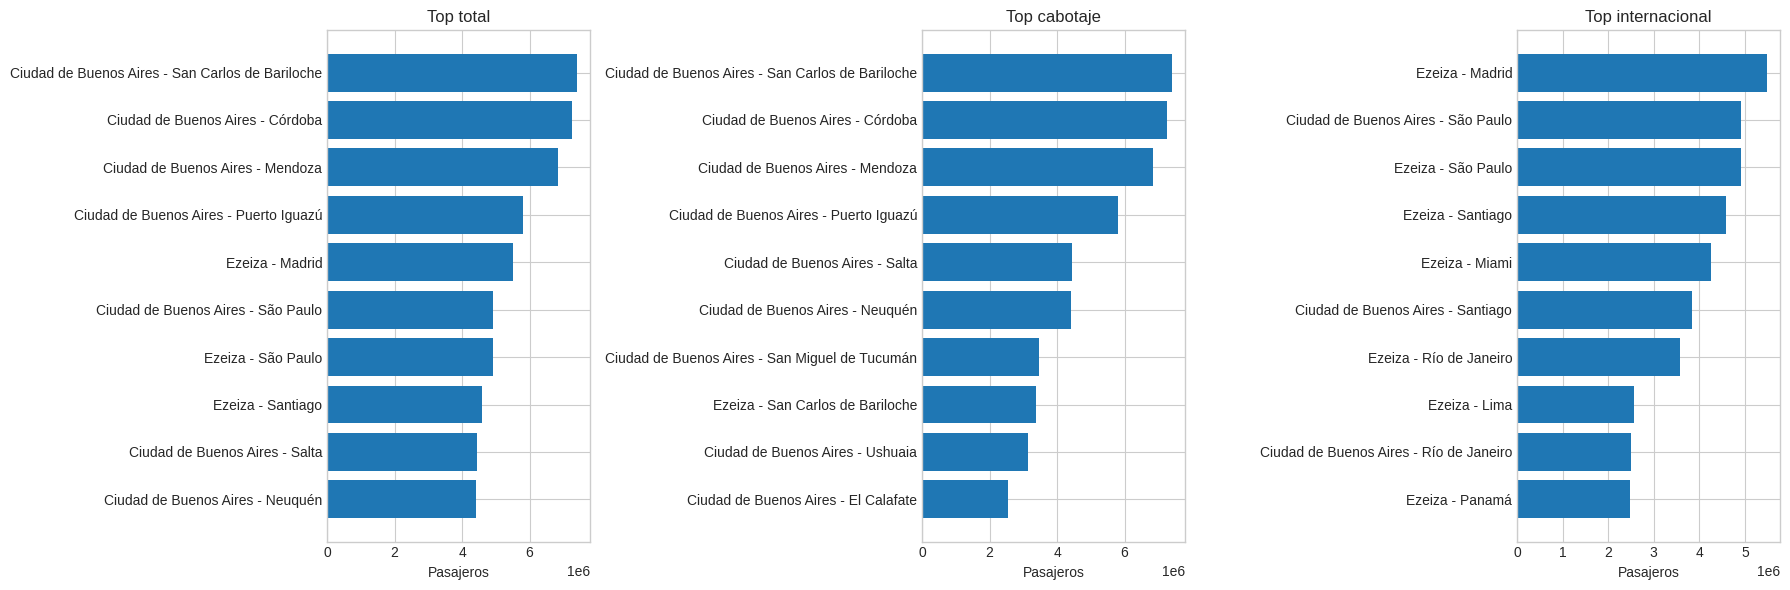

Conclusión: la ruta con mayor volumen total es Ciudad de Buenos Aires - San Carlos de Bariloche (7,419,737 pasajeros). En cabotaje lidera Ciudad de Buenos Aires - San Carlos de Bariloche y en internacional Ezeiza - Madrid. Estas rutas son candidatas naturales para reforzar capacidad, frecuencias o seguimiento operativo.


In [39]:
top_rutas = conectividad.groupby(['Clasificacion', 'Ruta']).agg(
    vuelos=('Vuelos', 'sum'),
    pasajeros=('Pasajeros', 'sum'),
    asientos=('Asientos', 'sum'),
).reset_index()
top_rutas['ocupacion'] = np.where(top_rutas['asientos'] > 0, top_rutas['pasajeros'] / top_rutas['asientos'], np.nan)

top_total = (
    top_rutas.groupby('Ruta').agg(
        vuelos=('vuelos', 'sum'),
        pasajeros=('pasajeros', 'sum'),
        asientos=('asientos', 'sum')
    )
    .reset_index()
)
top_total['ocupacion'] = top_total['pasajeros'] / top_total['asientos']
top_total = top_total.sort_values('pasajeros', ascending=False).head(10)

top_cabotaje = top_rutas[top_rutas['Clasificacion'] == 'Cabotaje'].sort_values('pasajeros', ascending=False).head(10)
top_internacional = top_rutas[top_rutas['Clasificacion'] == 'Internacional'].sort_values('pasajeros', ascending=False).head(10)

print('Top 10 total')
display(top_total)
print('Top 10 cabotaje')
display(top_cabotaje)
print('Top 10 internacional')
display(top_internacional)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, datos, titulo in [
    (axes[0], top_total.sort_values('pasajeros'), 'Top total'),
    (axes[1], top_cabotaje.sort_values('pasajeros'), 'Top cabotaje'),
    (axes[2], top_internacional.sort_values('pasajeros'), 'Top internacional'),
]:
    ax.barh(datos['Ruta'], datos['pasajeros'])
    ax.set_title(titulo)
    ax.set_xlabel('Pasajeros')
plt.tight_layout()
plt.show()

ruta_total = top_total.iloc[0]
ruta_cabotaje = top_cabotaje.iloc[0]
ruta_internacional = top_internacional.iloc[0]
print(
    f"Conclusión: la ruta con mayor volumen total es {ruta_total['Ruta']} "
    f"({ruta_total['pasajeros']:,.0f} pasajeros). En cabotaje lidera {ruta_cabotaje['Ruta']} "
    f"y en internacional {ruta_internacional['Ruta']}. Estas rutas son candidatas naturales para reforzar capacidad, frecuencias o seguimiento operativo."
)

# ¿Cómo se comporta la ocupación y cómo se define alta ocupación?

La alta ocupación se define con la mediana de cada clasificación. Esto evita usar un umbral único que podría no representar igual a cabotaje e internacional.

,Clasificacion,registros,vuelos,pasajeros,asientos,ocupacion_media,ocupacion_mediana,registros_imputados,proporcion_alta_ocupacion
0,Cabotaje,446911,787985,95117060,113020355,81.425757,85.338346,7,50.008838
1,Internacional,318422,458334,75014530,91510101,80.799683,85.393258,69,50.001884


,Clasificacion,umbral_alta_ocupacion_%
0,Cabotaje,85.338346
1,Internacional,85.393258


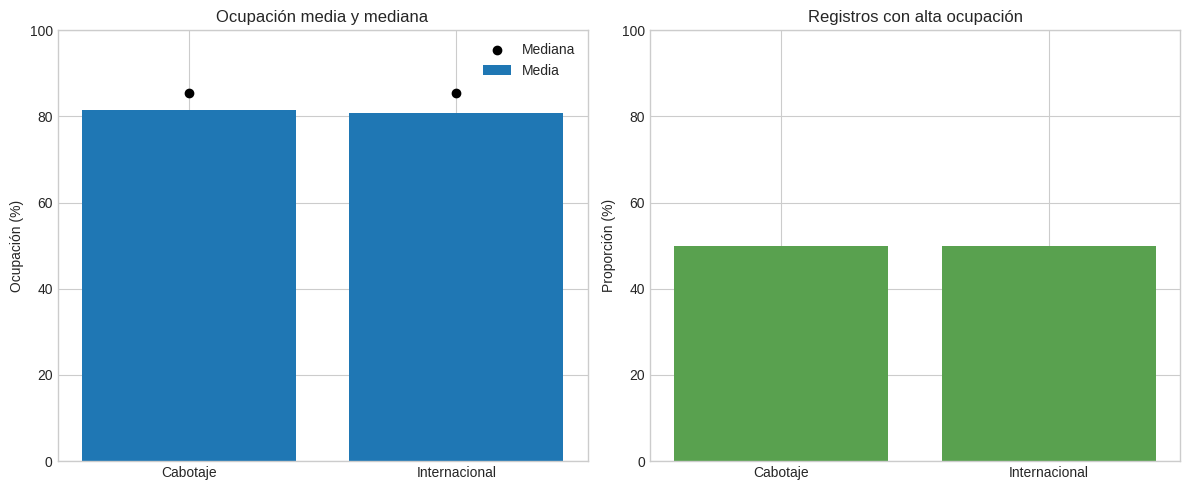

Conclusión: se imputaron 76 valores nulos de ocupación con la media de su clasificación. La ocupación es alta en ambos segmentos y el KPI de alta ocupación queda definido por la mediana propia de cada grupo, no por un valor arbitrario.


In [40]:
resumen_ocupacion = conectividad.groupby('Clasificacion').agg(
    registros=('Ruta', 'count'),
    vuelos=('Vuelos', 'sum'),
    pasajeros=('Pasajeros', 'sum'),
    asientos=('Asientos', 'sum'),
    ocupacion_media=('ocupacion', 'mean'),
    ocupacion_mediana=('ocupacion', 'median'),
    registros_imputados=('ocupacion_fue_imputada', 'sum'),
    proporcion_alta_ocupacion=('alta_ocupacion', 'mean'),
).reset_index()

for columna in ['ocupacion_media', 'ocupacion_mediana', 'proporcion_alta_ocupacion']:
    resumen_ocupacion[columna] *= 100

umbral_df = (umbral_alta_ocupacion * 100).rename('umbral_alta_ocupacion_%').reset_index()

display(resumen_ocupacion)
display(umbral_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(resumen_ocupacion['Clasificacion'], resumen_ocupacion['ocupacion_media'], label='Media')
axes[0].scatter(resumen_ocupacion['Clasificacion'], resumen_ocupacion['ocupacion_mediana'], color='black', label='Mediana', zorder=3)
axes[0].set_title('Ocupación media y mediana')
axes[0].set_ylabel('Ocupación (%)')
axes[0].set_ylim(0, 100)
axes[0].legend()

axes[1].bar(resumen_ocupacion['Clasificacion'], resumen_ocupacion['proporcion_alta_ocupacion'], color='#59a14f')
axes[1].set_title('Registros con alta ocupación')
axes[1].set_ylabel('Proporción (%)')
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()

imputados = int(conectividad['ocupacion_fue_imputada'].sum())
print(
    f"Conclusión: se imputaron {imputados} valores nulos de ocupación con la media de su clasificación. "
    f"La ocupación es alta en ambos segmentos y el KPI de alta ocupación queda definido por la mediana propia de cada grupo, "
    f"no por un valor arbitrario."
)

# ¿Qué valores atípicos aparecen en la serie histórica y cómo se interpretan?

Se observan pasajeros anuales hasta 2025 para evitar que 2026 parcial distorsione la tendencia. Además se revisan días extremos para detectar caídas, picos y posibles registros atípicos.

Pasajeros anuales por clasificación


,anio,Clasificacion,Pasajeros
0,2019,Cabotaje,15965999
1,2019,Internacional,14294082
2,2020,Cabotaje,3600497
3,2020,Internacional,3367484
4,2021,Cabotaje,6037412
5,2021,Internacional,1947298
6,2022,Cabotaje,13454917
7,2022,Internacional,8093235
8,2023,Cabotaje,17229196
9,2023,Internacional,11668342


Días con pasajeros muy bajos, excluyendo 2026 parcial


,fecha,Pasajeros
508,2020-05-28,17
473,2020-04-21,25
589,2020-08-22,50
619,2020-09-21,51
549,2020-07-09,55
476,2020-04-24,65
478,2020-04-26,78
533,2020-06-22,89
568,2020-08-01,133
592,2020-08-25,133


Días con pasajeros muy altos, excluyendo 2026 parcial


,fecha,Pasajeros
2543,2025-12-28,117294
2534,2025-12-19,111009
2536,2025-12-21,110376
2535,2025-12-20,110246
2241,2025-03-01,109396
2545,2025-12-30,108712
2529,2025-12-14,108698
2214,2025-02-02,106905
2544,2025-12-29,106750
2185,2025-01-04,106716


Extremos bajos de 2024


,fecha,Pasajeros
1945,2024-05-09,9265
1839,2024-01-24,13112
1874,2024-02-28,14103
2119,2024-10-30,19989
1950,2024-05-14,58939


Extremos altos de 2024


,fecha,Pasajeros
2171,2024-12-21,102988
2178,2024-12-28,102346
2177,2024-12-27,101742
2176,2024-12-26,101400
2180,2024-12-30,101230


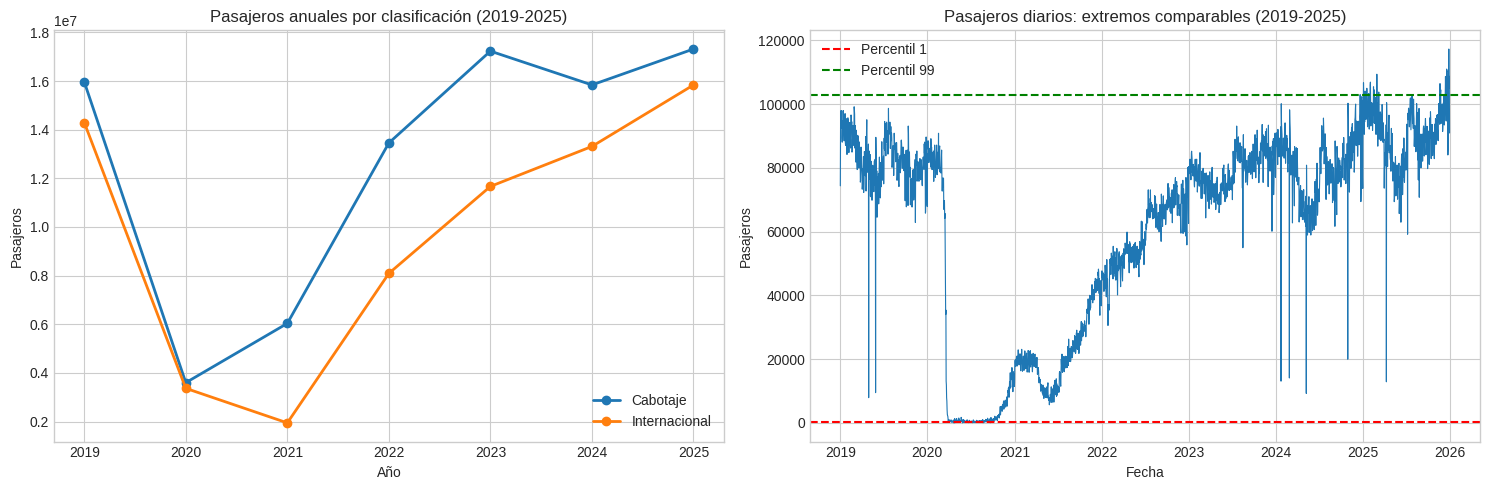

Conclusión: la caída de 2020 frente a 2019 fue de 76.97% y se interpreta por el impacto de la pandemia. En 2024, el menor día registrado fue 2024-05-09 con 9,265 pasajeros y el mayor fue 2024-12-21 con 102,988. Esos extremos deben revisarse antes de usarlos para decisiones: pueden representar picos reales, estacionalidad o carga parcial.


In [41]:
conectividad_anual = conectividad[conectividad['anio'].between(2019, 2025)].copy()
pasajeros_anuales = conectividad_anual.groupby(['anio', 'Clasificacion'])['Pasajeros'].sum().reset_index()

pasajeros_diarios = conectividad.groupby(['fecha', 'Clasificacion'])['Pasajeros'].sum().reset_index()
pasajeros_diarios_total = conectividad.groupby('fecha')['Pasajeros'].sum().reset_index()
pasajeros_diarios_total['anio'] = pasajeros_diarios_total['fecha'].dt.year

# Para detectar extremos comparables se excluye 2026 porque es un año parcial.
pasajeros_diarios_completo = pasajeros_diarios_total[pasajeros_diarios_total['anio'].between(2019, 2025)].copy()
q01 = pasajeros_diarios_completo['Pasajeros'].quantile(0.01)
q99 = pasajeros_diarios_completo['Pasajeros'].quantile(0.99)
atipicos_bajos = pasajeros_diarios_completo[pasajeros_diarios_completo['Pasajeros'] <= q01].sort_values('Pasajeros').head(10)
atipicos_altos = pasajeros_diarios_completo[pasajeros_diarios_completo['Pasajeros'] >= q99].sort_values('Pasajeros', ascending=False).head(10)

# Revisión puntual de 2024, mencionada en la discusión de clase.
pasajeros_2024_diarios = pasajeros_diarios_total[pasajeros_diarios_total['anio'] == 2024].copy()
extremos_2024_bajos = pasajeros_2024_diarios.sort_values('Pasajeros').head(5)
extremos_2024_altos = pasajeros_2024_diarios.sort_values('Pasajeros', ascending=False).head(5)

print('Pasajeros anuales por clasificación')
display(pasajeros_anuales)
print('Días con pasajeros muy bajos, excluyendo 2026 parcial')
display(atipicos_bajos[['fecha', 'Pasajeros']])
print('Días con pasajeros muy altos, excluyendo 2026 parcial')
display(atipicos_altos[['fecha', 'Pasajeros']])
print('Extremos bajos de 2024')
display(extremos_2024_bajos[['fecha', 'Pasajeros']])
print('Extremos altos de 2024')
display(extremos_2024_altos[['fecha', 'Pasajeros']])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for clasificacion, datos in pasajeros_anuales.groupby('Clasificacion'):
    axes[0].plot(datos['anio'], datos['Pasajeros'], marker='o', linewidth=2, label=clasificacion)
axes[0].set_title('Pasajeros anuales por clasificación (2019-2025)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Pasajeros')
axes[0].legend()

axes[1].plot(pasajeros_diarios_completo['fecha'], pasajeros_diarios_completo['Pasajeros'], linewidth=0.8)
axes[1].axhline(q01, color='red', linestyle='--', label='Percentil 1')
axes[1].axhline(q99, color='green', linestyle='--', label='Percentil 99')
axes[1].set_title('Pasajeros diarios: extremos comparables (2019-2025)')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Pasajeros')
axes[1].legend()
plt.tight_layout()
plt.show()

pasajeros_2019 = pasajeros_anuales.loc[pasajeros_anuales['anio'] == 2019, 'Pasajeros'].sum()
pasajeros_2020 = pasajeros_anuales.loc[pasajeros_anuales['anio'] == 2020, 'Pasajeros'].sum()
caida_2020 = (1 - pasajeros_2020 / pasajeros_2019) * 100
max_2024 = extremos_2024_altos.iloc[0]
min_2024 = extremos_2024_bajos.iloc[0]

print(
    f"Conclusión: la caída de 2020 frente a 2019 fue de {caida_2020:.2f}% y se interpreta por el impacto de la pandemia. "
    f"En 2024, el menor día registrado fue {min_2024['fecha'].date()} con {min_2024['Pasajeros']:,.0f} pasajeros "
    f"y el mayor fue {max_2024['fecha'].date()} con {max_2024['Pasajeros']:,.0f}. "
    f"Esos extremos deben revisarse antes de usarlos para decisiones: pueden representar picos reales, estacionalidad o carga parcial."
)

# ¿Cuál es el comportamiento general de las demoras?

count    336687.000000
mean         19.236591
std          44.550427
min        -179.000000
25%          -2.000000
50%          10.000000
75%          25.000000
90%          56.000000
95%          96.000000
max         360.000000
Name: delta_minutos, dtype: float64

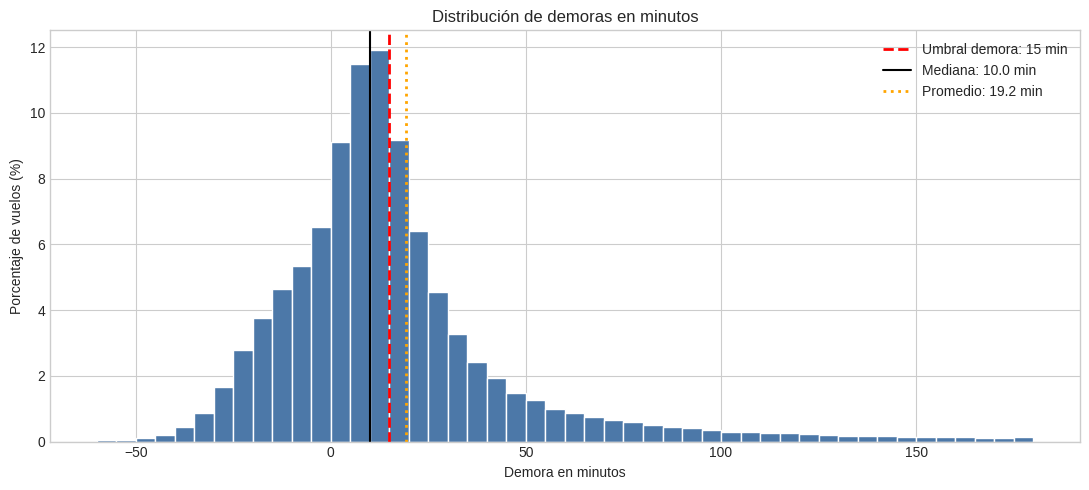

Conclusión: la demora promedio es 19.24 minutos, la mediana es 10.00 minutos y el 38.49% de los vuelos supera los 15 minutos de demora. La media mayor que la mediana indica una cola de demoras altas.


In [42]:
resumen_demoras = failbondi_limpio['delta_minutos'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
media_demora = failbondi_limpio['delta_minutos'].mean()
mediana_demora = failbondi_limpio['delta_minutos'].median()
porcentaje_demora_15 = failbondi_limpio['demorado_15m'].mean() * 100
porcentaje_adelanto_5 = failbondi_limpio['adelantado_5m'].mean() * 100
hora_mas_vuelos_failbondi = failbondi_limpio['hora'].mode().iloc[0]

display(resumen_demoras)

rango_visual = (-60, 180)
demoras = failbondi_limpio['delta_minutos'].dropna()
demoras_grafico = demoras[demoras.between(*rango_visual)]
pesos = np.ones(len(demoras_grafico)) / len(demoras) * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(
    demoras_grafico,
    bins=np.arange(rango_visual[0], rango_visual[1] + 5, 5),
    weights=pesos,
    color='#4c78a8',
    edgecolor='white',
)
ax.axvline(15, color='red', linestyle='--', linewidth=2, label='Umbral demora: 15 min')
ax.axvline(mediana_demora, color='black', linewidth=1.5, label=f'Mediana: {mediana_demora:.1f} min')
ax.axvline(media_demora, color='orange', linestyle=':', linewidth=2, label=f'Promedio: {media_demora:.1f} min')
ax.set_title('Distribución de demoras en minutos')
ax.set_xlabel('Demora en minutos')
ax.set_ylabel('Porcentaje de vuelos (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Conclusión: la demora promedio es {media_demora:.2f} minutos, la mediana es {mediana_demora:.2f} minutos "
    f"y el {porcentaje_demora_15:.2f}% de los vuelos supera los 15 minutos de demora. La media mayor que la mediana indica una cola de demoras altas."
)

# ¿Las demoras cambian según tipo de movimiento y aerolínea?

Demora por tipo de movimiento


,tipo_movimiento,vuelos,prob_demora_15m,demora_promedio_min,demora_mediana_min
0,Arribo,109669,19.934530,4.437507,-7.0
1,Partida,227018,47.449101,26.385806,15.0


Top aerolíneas por probabilidad de demora, con al menos 100 vuelos


,aerolinea,vuelos,prob_demora_15m,demora_promedio_min,demora_mediana_min
14,BOLIVIANA DE AVIACION,1292,64.473684,43.496130,28.5
5,AIR FRANCE,751,61.784288,25.366178,20.0
21,FLYBONDI,39246,58.242878,45.838277,21.0
12,AVIANCA ECUADOR,559,52.951699,22.694097,17.0
20,ETHIOPIAN AIRLINES,765,52.810458,35.679739,18.0
18,DHL AERO EXPRESO,672,51.339286,18.523810,16.0
9,ARAJET,1586,50.063052,28.600883,16.0
28,KLM,1505,46.777409,18.134884,14.0
17,DELTA AIR LINES,1365,46.739927,20.832967,15.0
10,AVIANCA,3746,46.502936,18.798185,14.0


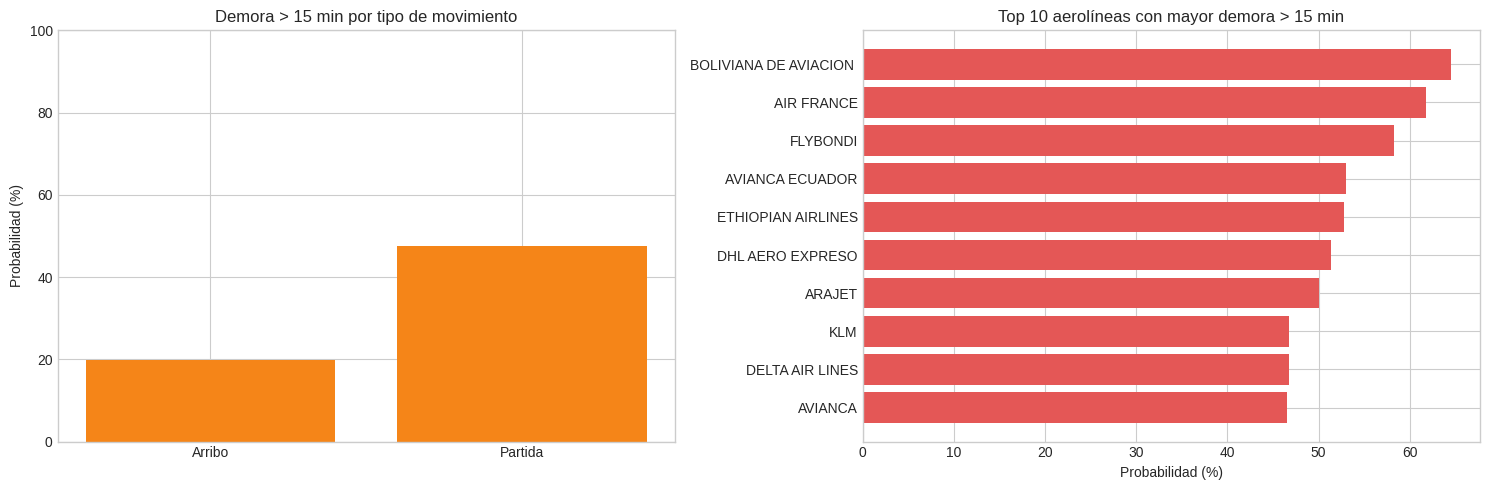

Conclusión: las partidas tienen mayor probabilidad de demora (47.45%) que los arribos (19.93%). Entre aerolíneas con al menos 100 vuelos, la mayor probabilidad observada corresponde a BOLIVIANA DE AVIACION  (64.47%).


In [43]:
prob_demora_por_movimiento = failbondi_limpio.groupby('tipo_movimiento').agg(
    vuelos=('flight_id', 'count'),
    prob_demora_15m=('demorado_15m', 'mean'),
    demora_promedio_min=('delta_minutos', 'mean'),
    demora_mediana_min=('delta_minutos', 'median'),
).reset_index()
prob_demora_por_movimiento['prob_demora_15m'] *= 100

min_vuelos_aerolinea = 100
prob_demora_por_aerolinea = failbondi_limpio.groupby('aerolinea').agg(
    vuelos=('flight_id', 'count'),
    prob_demora_15m=('demorado_15m', 'mean'),
    demora_promedio_min=('delta_minutos', 'mean'),
    demora_mediana_min=('delta_minutos', 'median'),
).query('vuelos >= @min_vuelos_aerolinea').reset_index()
prob_demora_por_aerolinea['prob_demora_15m'] *= 100
top_demora_aerolinea = prob_demora_por_aerolinea.sort_values('prob_demora_15m', ascending=False).head(10)

print('Demora por tipo de movimiento')
display(prob_demora_por_movimiento)
print('Top aerolíneas por probabilidad de demora, con al menos 100 vuelos')
display(top_demora_aerolinea)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(prob_demora_por_movimiento['tipo_movimiento'], prob_demora_por_movimiento['prob_demora_15m'], color='#f58518')
axes[0].set_title('Demora > 15 min por tipo de movimiento')
axes[0].set_ylabel('Probabilidad (%)')
axes[0].set_ylim(0, 100)

datos_aero = top_demora_aerolinea.sort_values('prob_demora_15m')
axes[1].barh(datos_aero['aerolinea'], datos_aero['prob_demora_15m'], color='#e45756')
axes[1].set_title('Top 10 aerolíneas con mayor demora > 15 min')
axes[1].set_xlabel('Probabilidad (%)')
plt.tight_layout()
plt.show()

partidas = prob_demora_por_movimiento.loc[prob_demora_por_movimiento['tipo_movimiento'] == 'Partida', 'prob_demora_15m'].iloc[0]
arribos = prob_demora_por_movimiento.loc[prob_demora_por_movimiento['tipo_movimiento'] == 'Arribo', 'prob_demora_15m'].iloc[0]
aerolinea_top = top_demora_aerolinea.iloc[0]
print(
    f"Conclusión: las partidas tienen mayor probabilidad de demora ({partidas:.2f}%) que los arribos ({arribos:.2f}%). "
    f"Entre aerolíneas con al menos {min_vuelos_aerolinea} vuelos, la mayor probabilidad observada corresponde a {aerolinea_top['aerolinea']} "
    f"({aerolinea_top['prob_demora_15m']:.2f}%)."
)

## Probabilidad total de demora según el tipo de movimiento

Se considera como demora relevante que un vuelo supere los 15 minutos.

Definimos los eventos:

- \(D\): el vuelo tiene una demora mayor a 15 minutos.
- \(P\): el movimiento es una partida.
- \(A\): el movimiento es un arribo.

La probabilidad de demora cambia según el tipo de movimiento:

- \(P(D \mid P)\): probabilidad de demora dado que es una partida.
- \(P(D \mid A)\): probabilidad de demora dado que es un arribo.

Como todo movimiento analizado es una partida o un arribo, ambos grupos forman una partición del conjunto de vuelos. Por lo tanto, se puede aplicar el teorema de la probabilidad total:

\[
P(D) = P(D \mid P)\cdot P(P) + P(D \mid A)\cdot P(A)
\]

La pregunta que se busca responder es:

> Si se selecciona un vuelo al azar, ¿cuál es la probabilidad total de que tenga más de 15 minutos de demora, considerando la proporción de partidas y arribos?

In [44]:
# Demora superior a 15 minutos
# Partidas y arribos forman los dos grupos del análisis.

total_vuelos = len(failbondi_limpio)

es_partida = failbondi_limpio['tipo_movimiento'] == 'Partida'
es_arribo = failbondi_limpio['tipo_movimiento'] == 'Arribo'

# Probabilidades de cada tipo de movimiento
prob_partida = es_partida.mean()
prob_arribo = es_arribo.mean()

# Probabilidades condicionales de demora
prob_demora_dada_partida = (
    failbondi_limpio.loc[es_partida, 'demorado_15m'].mean()
)

prob_demora_dado_arribo = (
    failbondi_limpio.loc[es_arribo, 'demorado_15m'].mean()
)

# Teorema de la probabilidad total
prob_demora_total = (
    prob_demora_dada_partida * prob_partida
    + prob_demora_dado_arribo * prob_arribo
)

# Probabilidad observada directamente, para verificar el resultado
prob_demora_empirica = failbondi_limpio['demorado_15m'].mean()

resumen_probabilidad_total = pd.DataFrame({
    'Concepto': [
        'P(Partida)',
        'P(Arribo)',
        'P(Demora | Partida)',
        'P(Demora | Arribo)',
        'P(Demora) por probabilidad total',
        'P(Demora) observada directamente'
    ],
    'Probabilidad': [
        prob_partida,
        prob_arribo,
        prob_demora_dada_partida,
        prob_demora_dado_arribo,
        prob_demora_total,
        prob_demora_empirica
    ]
})

resumen_probabilidad_total['Porcentaje'] = (
    resumen_probabilidad_total['Probabilidad'] * 100
)

display(resumen_probabilidad_total.round(4))

print(
    f"La probabilidad total de que un vuelo tenga más de 15 minutos "
    f"de demora es {prob_demora_total * 100:.2f}%."
)

print(
    f"La frecuencia observada directamente es "
    f"{prob_demora_empirica * 100:.2f}%."
)

,Concepto,Probabilidad,Porcentaje
0,P(Partida),0.6743,67.4270
1,P(Arribo),0.3257,32.5730
2,P(Demora | Partida),0.4745,47.4491
3,P(Demora | Arribo),0.1993,19.9345
4,P(Demora) por probabilidad total,0.3849,38.4868
5,P(Demora) observada directamente,0.3849,38.4868


La probabilidad total de que un vuelo tenga más de 15 minutos de demora es 38.49%.
La frecuencia observada directamente es 38.49%.


### Interpretación

La probabilidad total de que un vuelo tenga más de 15 minutos de demora es aproximadamente **38,49%**.

Este resultado combina:

- La probabilidad de demora de las partidas, aproximadamente **47,45%**.
- La probabilidad de demora de los arribos, aproximadamente **19,93%**.
- La proporción que representa cada tipo de movimiento dentro del dataset.

El resultado coincide con la frecuencia general de demoras observada directamente en los datos. Esto verifica que la aplicación del teorema de la probabilidad total es correcta.

La probabilidad general se encuentra más cerca de la correspondiente a las partidas porque estas representan una proporción mayor de los movimientos analizados. En términos operativos, el resultado refuerza la recomendación de concentrar las medidas de mejora en los procesos previos a la salida de los vuelos.

# ¿Las demoras varían según hora del día y día de semana?

Demoras por hora


,hora,vuelos,prob_demora_15m,demora_promedio_min
0,0,5326,33.683815,17.571724
1,1,5030,33.081511,12.006362
2,2,4881,38.373284,18.175374
3,3,4323,27.411520,11.996068
4,4,6650,22.796992,9.566617
5,5,11706,29.856484,12.858876
6,6,12212,37.381264,18.206109
7,7,19026,34.568485,14.785872
8,8,16847,35.917374,15.544963
9,9,17299,34.059772,14.359501


Demoras por día


,dia_semana,vuelos,prob_demora_15m,demora_promedio_min
0,Lunes,49822,39.930151,19.988860
1,Martes,46772,36.526127,17.848927
2,Miércoles,46073,38.070019,18.397022
3,Jueves,47780,39.133529,19.411448
4,Viernes,49376,41.542450,21.846828
5,Sábado,47621,37.397367,18.609689
6,Domingo,49243,36.640741,18.398331


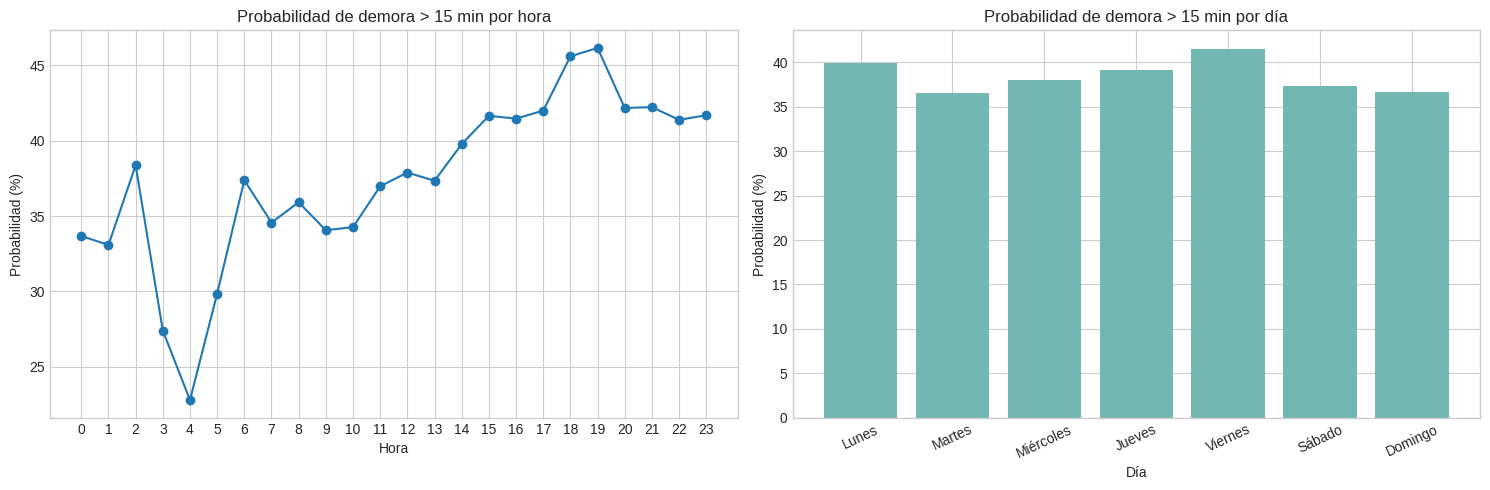

Conclusión: la mayor probabilidad de demora por hora aparece a las 19:00 (46.15%). Por día de semana, el peor valor se observa el Viernes (41.54%).


In [45]:
demora_por_hora = failbondi_limpio.groupby('hora').agg(
    vuelos=('flight_id', 'count'),
    prob_demora_15m=('demorado_15m', 'mean'),
    demora_promedio_min=('delta_minutos', 'mean'),
).reset_index()
demora_por_hora['prob_demora_15m'] *= 100

demora_por_dia = failbondi_limpio.groupby('dia_semana').agg(
    vuelos=('flight_id', 'count'),
    prob_demora_15m=('demorado_15m', 'mean'),
    demora_promedio_min=('delta_minutos', 'mean'),
).reindex(ORDEN_DIAS).reset_index()
demora_por_dia['prob_demora_15m'] *= 100

print('Demoras por hora')
display(demora_por_hora)
print('Demoras por día')
display(demora_por_dia)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(demora_por_hora['hora'], demora_por_hora['prob_demora_15m'], marker='o')
axes[0].set_title('Probabilidad de demora > 15 min por hora')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Probabilidad (%)')
axes[0].set_xticks(range(24))

axes[1].bar(demora_por_dia['dia_semana'], demora_por_dia['prob_demora_15m'], color='#72b7b2')
axes[1].set_title('Probabilidad de demora > 15 min por día')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Probabilidad (%)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

hora_peor = demora_por_hora.loc[demora_por_hora['prob_demora_15m'].idxmax()]
dia_peor = demora_por_dia.loc[demora_por_dia['prob_demora_15m'].idxmax()]
print(
    f"Conclusión: la mayor probabilidad de demora por hora aparece a las {int(hora_peor['hora'])}:00 "
    f"({hora_peor['prob_demora_15m']:.2f}%). Por día de semana, el peor valor se observa el {dia_peor['dia_semana']} "
    f"({dia_peor['prob_demora_15m']:.2f}%)."
)

# ¿Qué probabilidades pueden estimarse con modelos binomial y Poisson?

Se usan dos enfoques probabilísticos, pero con una aclaración importante:

- **Binomial:** si se observan 20 vuelos, ¿cuál es la probabilidad de que al menos 10 tengan demora mayor a 15 minutos?
- **Poisson:** se contrasta si sirve para modelar la cantidad diaria de vuelos demorados. Para una Poisson, la media y la varianza deberían ser parecidas; si la varianza real es mucho mayor, el modelo no ajusta bien y conviene usar la frecuencia empírica.


,modelo,pregunta,parametros,probabilidad,porcentaje,interpretacion
0,Binomial,P(al menos 10 demoras en 20 vuelos),"n=20, p=0.3849",0.202381,20.238107,Modelo útil como aproximación simple
1,Poisson teórica,P(más de 300 demoras en un día),lambda=251.61,0.001351,0.135101,No ajusta bien: hay sobredispersión
2,Frecuencia empírica,P(más de 300 demoras en un día),datos observados,0.277670,27.766990,Más representativa para estos datos


count    515.00000
mean     251.61165
std       84.60890
min       18.00000
25%      189.00000
50%      236.00000
75%      307.00000
max      608.00000
Name: demorado_15m, dtype: float64

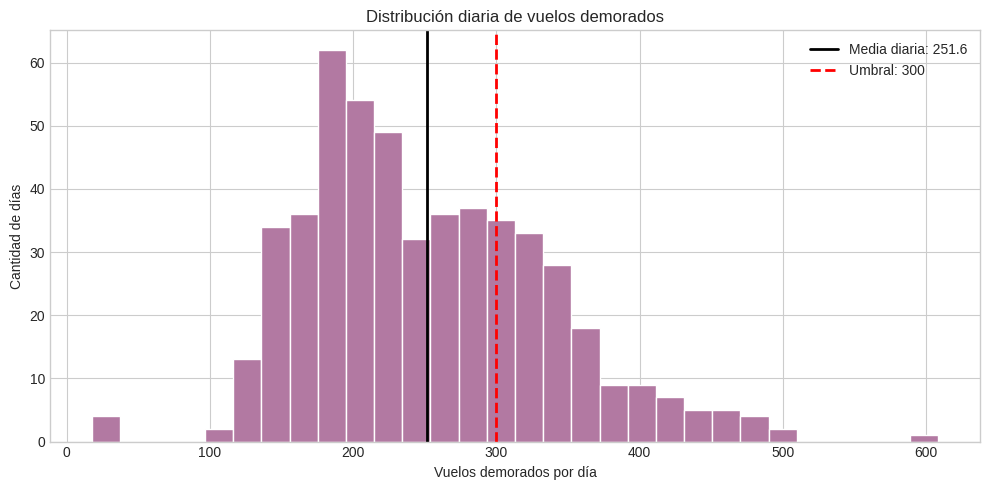

Conclusión: con p=0.3849, la probabilidad binomial de que al menos 10 de 20 vuelos estén demorados es 20.24%. Para Poisson, la media diaria es 251.61 y la varianza es 7158.67, con índice de dispersión 28.45. Como la varianza es mucho mayor que la media, Poisson no ajusta bien: estima 0.14% para más de 300 demoras, pero la frecuencia empírica es 27.77%.


In [46]:
p_demora = failbondi_limpio['demorado_15m'].mean()
n = 20
k_min = 10
prob_binomial_al_menos_10 = sum(
    comb(n, k) * (p_demora ** k) * ((1 - p_demora) ** (n - k))
    for k in range(k_min, n + 1)
)

demoras_por_fecha = failbondi_limpio.groupby('fecha')['demorado_15m'].sum()
lambda_diaria = demoras_por_fecha.mean()
varianza_diaria = demoras_por_fecha.var()
indice_dispersion = varianza_diaria / lambda_diaria
umbral_poisson = 300
prob_poisson_mas_300 = poisson.sf(umbral_poisson, lambda_diaria)
prob_empirica_mas_300 = (demoras_por_fecha > umbral_poisson).mean()

probabilidades_modelos = pd.DataFrame([
    {
        'modelo': 'Binomial',
        'pregunta': 'P(al menos 10 demoras en 20 vuelos)',
        'parametros': f'n={n}, p={p_demora:.4f}',
        'probabilidad': prob_binomial_al_menos_10,
        'porcentaje': prob_binomial_al_menos_10 * 100,
        'interpretacion': 'Modelo útil como aproximación simple',
    },
    {
        'modelo': 'Poisson teórica',
        'pregunta': 'P(más de 300 demoras en un día)',
        'parametros': f'lambda={lambda_diaria:.2f}',
        'probabilidad': prob_poisson_mas_300,
        'porcentaje': prob_poisson_mas_300 * 100,
        'interpretacion': 'No ajusta bien: hay sobredispersión',
    },
    {
        'modelo': 'Frecuencia empírica',
        'pregunta': 'P(más de 300 demoras en un día)',
        'parametros': 'datos observados',
        'probabilidad': prob_empirica_mas_300,
        'porcentaje': prob_empirica_mas_300 * 100,
        'interpretacion': 'Más representativa para estos datos',
    },
])

display(probabilidades_modelos)
display(demoras_por_fecha.describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(demoras_por_fecha, bins=30, color='#b279a2', edgecolor='white')
ax.axvline(lambda_diaria, color='black', linewidth=2, label=f'Media diaria: {lambda_diaria:.1f}')
ax.axvline(umbral_poisson, color='red', linestyle='--', linewidth=2, label='Umbral: 300')
ax.set_title('Distribución diaria de vuelos demorados')
ax.set_xlabel('Vuelos demorados por día')
ax.set_ylabel('Cantidad de días')
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Conclusión: con p={p_demora:.4f}, la probabilidad binomial de que al menos 10 de 20 vuelos estén demorados es "
    f"{prob_binomial_al_menos_10 * 100:.2f}%. Para Poisson, la media diaria es {lambda_diaria:.2f} y la varianza "
    f"es {varianza_diaria:.2f}, con índice de dispersión {indice_dispersion:.2f}. Como la varianza es mucho mayor que la media, "
    f"Poisson no ajusta bien: estima {prob_poisson_mas_300 * 100:.2f}% para más de 300 demoras, pero la frecuencia empírica es "
    f"{prob_empirica_mas_300 * 100:.2f}%."
)

# Conclusion de la primer parte

El problema trabajado fue identificar patrones de demanda, ocupación y puntualidad del transporte aéreo argentino para convertir datos operativos en conclusiones útiles. Para eso se integraron tres fuentes locales: conectividad aérea, movimientos aeroportuarios de ANAC y demoras de Failbondi.

Los datos muestran que la demanda no se distribuye de forma uniforme. En ANAC, usando `PAX` como pasajeros equivalentes, la mayor concentración horaria se observa a las **00:00** y la menor a las **5:00**. A nivel semanal, el día de mayor movimiento es **sábado** y el menor es **miércoles**. A nivel mensual, **enero** concentra el mayor volumen y **junio** el menor. Estos resultados permiten anticipar necesidades de capacidad, personal y planificación operativa.

En conectividad, las rutas de mayor tráfico están muy concentradas: **Ciudad de Buenos Aires - San Carlos de Bariloche** lidera el ranking total. Separar cabotaje e internacional evita conclusiones mezcladas y permite ver qué rutas deberían recibir seguimiento prioritario según el mercado analizado. La ocupación es elevada en ambos segmentos: media de **81,43%** en cabotaje y **80,80%** en internacional; las medianas son **85,34%** y **85,39%**, respectivamente. El KPI de alta ocupación se definió con la mediana propia de cada clasificación, no con un umbral arbitrario.

La serie histórica evidencia una caída marcada en 2020, consistente con el impacto de la pandemia. Ese punto no debería eliminarse automáticamente porque tiene explicación de dominio y aporta contexto. En 2024 también aparecen días extremos: el menor registro fue el **09/05/2024** con **9.265 pasajeros** y el mayor fue el **21/12/2024** con **102.988 pasajeros**. Estos valores deben revisarse antes de usarlos para decisiones, porque pueden representar picos reales, estacionalidad o carga parcial.

El análisis de demoras es uno de los resultados más accionables. Luego del recorte y limpieza de Failbondi, la demora promedio es **19,24 minutos**, la mediana es **10 minutos** y el **38,49%** de los vuelos supera los 15 minutos de demora. Las partidas presentan una probabilidad de demora mayor que los arribos (**47,45%** contra **19,93%**), lo que sugiere que las acciones de mejora deberían concentrarse especialmente en procesos previos a la salida.

Desde el punto de vista probabilístico, si se observan **20** vuelos, la probabilidad de que al menos 10 estén demorados es **20,24%**. Además, la cantidad diaria de demoras muestra sobredispersión: la media es **251,61** y la varianza es mucho mayor. Por eso, Poisson no ajusta bien para este caso: estima **0,14%** para superar 300 demoras en un día, mientras que la frecuencia empírica observada es **27,77%**. Este contraste es útil porque muestra cuándo un modelo teórico no debe usarse para decidir sin validar sus supuestos.

En síntesis, el sistema aéreo analizado muestra alta ocupación, demanda concentrada en determinados horarios y rutas, y un problema de demoras más fuerte en partidas que en arribos. Las decisiones más razonables a partir de este análisis serían reforzar capacidad en rutas líderes, planificar recursos según hora, día y mes de demanda, monitorear rutas y aerolíneas con alta demora, y profundizar el estudio de valores atípicos antes de convertirlos en reglas operativas.


# PARTE II: San Carlos de Bariloche

## Objetivos y contexto del caso Bariloche
Como aplicación específica del análisis general, se estudia el aeropuerto de San Carlos de Bariloche. Este destino presenta una fuerte actividad turística y variaciones estacionales, especialmente durante la temporada invernal.
El análisis se plantea desde la perspectiva de un organismo de planificación turística municipal que necesita comprender la dinámica de los aterrizajes y despegues para anticipar períodos de mayor demanda y organizar los recursos vinculados con el aeropuerto y el transporte terrestre.
Debido al crecimiento sostenido del turismo, la infraestructura de la ciudad y el aeropuerto se ven exigidos, especialmente en las temporadas de invierno y verano.
Objetivo: El  organismo necesita entender la dinámica de los arribos y partidas para:
- Optimizar el transporte público y traslados: Ajustar las frecuencias de colectivos y servicios de traslados según el volumen de pasajeros por hora.
- Prever la saturación de la terminal: Identificar momentos críticos donde la cantidad de vuelos supere la capacidad operativa.
- Planificación estratégica: Utilizar modelos estadísticos para predecir flujos futuros basados en tendencias históricas.

# Preparación de los datos de Bariloche
Las librerias fueron cargadas al inicio del informe

In [47]:
# Filtrar únicamente los vuelos del aeropuerto de Bariloche (código IATA: BAR)
bariloche = anac[anac['Aeropuerto'] == 'BAR'].copy()

#Resumen general del dataset unificado ANAC 

print("CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC")
print()
#Cantidad de filas del dataset
print('Filas cabotaje:', len(anac[anac['Clasificación Vuelo'] == 'Doméstico']))
print('Filas internacional:', len(anac[anac['Clasificación Vuelo'] == 'Internacional']))
print('Filas totales:', len(anac))

# Rango temporal cubierto por el dataset
fecha_inicio = anac['Fecha UTC'].min()
fecha_fin    = anac['Fecha UTC'].max()

print()
print("RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC")
print()
print("Fecha de inicio del dataset:", fecha_inicio.strftime('%d/%m/%Y'))
print("Fecha fin del dataset:",       fecha_fin.strftime('%d/%m/%Y'))

print()
print("INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC")
print()
# Tipos de datos, cantidad de nulos y uso de memoria por columna
anac.info()


CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC

Filas cabotaje: 1540319
Filas internacional: 390539
Filas totales: 1930858

RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC

Fecha de inicio del dataset: 01/01/2023
Fecha fin del dataset: 30/04/2026

INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC

<class 'pandas.DataFrame'>
RangeIndex: 1930858 entries, 0 to 1930857
Data columns (total 18 columns):
 #   Column                             Dtype         
---  ------                             -----         
 0   Fecha UTC                          datetime64[us]
 1   Hora UTC                           str           
 2   Clase de Vuelo (todos los vuelos)  str           
 3   Clasificación Vuelo                str           
 4   Tipo de Movimiento                 str           
 5   Aeropuerto                         str           
 6   Origen / Destino                   str           
 7   Aerolinea Nombre                   str           
 8   Aeronave                           str 

In [48]:
# Visualización de las primeras filas para verificar la carga correcta del dataset
display(anac.head())


,Fecha UTC,Hora UTC,Clase de Vuelo (todos los vuelos),Clasificación Vuelo,Tipo de Movimiento,Aeropuerto,Origen / Destino,Aerolinea Nombre,Aeronave,Pasajeros,PAX,Calidad dato,pasajeros_movimiento,pasajeros_equivalentes,anio,mes,dia_semana,hora
0,2023-01-01,0:01,Regular,Internacional,Aterrizaje,EZE,LEMD,IBERIA - LINEAS AÉREAS DE ESPAÑA,0,199.0,199.0,DEFINITIVO,199.0,199.0,2023,1,Domingo,0
1,2023-01-01,0:10,Regular,Doméstico,Despegue,IGU,EZE,JETSMART AIRLINES S.A.,AIB-A320-232,67.0,33.5,DEFINITIVO,67.0,33.5,2023,1,Domingo,0
2,2023-01-01,0:15,Regular,Internacional,Aterrizaje,AER,SBPA,AEROLINEAS ARGENTINAS SA,BO-B-737-76N,36.0,36.0,DEFINITIVO,36.0,36.0,2023,1,Domingo,0
3,2023-01-01,0:17,Regular,Doméstico,Aterrizaje,SAL,AER,JETSMART AIRLINES S.A.,AIB-A320-232,168.0,84.0,DEFINITIVO,168.0,84.0,2023,1,Domingo,0
4,2023-01-01,0:19,Regular,Doméstico,Aterrizaje,AER,OSA,AEROLINEAS ARGENTINAS SA,EMB-ERJ190100IGW,17.0,8.5,DEFINITIVO,17.0,8.5,2023,1,Domingo,0


## Exploramos la cantidad de pasajeros que aterrizaron en los diferentes aeropuertos durante el periodo del dataset

In [49]:
# Total de pasajeros (PAX) que aterrizaron en cada aeropuerto durante el período del dataset.
# Se filtra solo por 'Aterrizaje' para no duplicar conteos con las salidas.
pax_por_aeropuerto = (
    anac[anac['Tipo de Movimiento'] == 'Aterrizaje']
        .groupby('Aeropuerto', as_index=False)['PAX']
        .sum()
        .sort_values('PAX', ascending=False)
)

print(pax_por_aeropuerto)

   Aeropuerto         PAX
0         AER  17166943.0
18        EZE  16119650.5
5         CBA   3238111.5
13        DOZ   2539284.0
2         BAR   2132946.0
25        IGU   1387828.5
42        SAL   1316572.5
33        NEU   1013301.0
53        USU    997192.5
16        ECA    775607.0
51        TUC    728409.5
39        ROS    572115.5
8         CRV    464079.5
27        JUJ    438404.5
37        POS    297106.0
6         CHP    260070.5
30        MDP    252232.5
49        TRE    238556.0
3         BCA    199202.0
7         CRR    194119.5
43        SDE    188601.0
44        SIS    175830.5
26        JUA    172480.5
21        GAL    149159.5
14        DRY    146745.0
24        GRA    110889.5
20        FSA     80962.5
17        ESQ     76905.0
4         CAT     75426.5
47        SVO     74426.0
28        LAR     62483.0
52        UIS     53637.0
45        SRA     39647.5
34        OSA     37966.0
36        PAR     37223.0
19        FDO     34194.0
54        VIE     29712.0
48        TR

# Limpieza y preparación de datos

In [50]:
# El archivo 2025 contiene filas con errores de formato que Pandas no puede leer.
# Este bloque cuantifica cuántas filas fueron descartadas durante la carga.

archivo = DATA_DIR / '202512-informe-ministerio-actualizado-dic-final.csv'

# Contar el total de líneas en el archivo (incluyendo encabezado y filas corruptas)
with open(archivo, encoding='utf-8') as f:
    total_lineas = sum(1 for _ in f)

# Cargar solo las filas válidas (on_bad_lines='skip' descarta las corruptas silenciosamente)
df_check = pd.read_csv(
    archivo,
    sep=';',
    decimal=',',
    engine='python',
    on_bad_lines='skip'
)

filas_validas   = len(df_check)
filas_ignoradas = total_lineas - filas_validas  # diferencia = filas corruptas + encabezado

print("Total de líneas:", total_lineas)
print("Filas cargadas:", filas_validas)
print("Filas ignoradas:", filas_ignoradas)


Total de líneas: 597785
Filas cargadas: 597784
Filas ignoradas: 1


In [51]:
# Tabla resumen con dimensiones del dataset unificado
resumen_datasets = pd.DataFrame({
    'dataset':  ['ANAC'],
    'filas':    [len(anac)],
    'columnas': [anac.shape[1]],
})
display(resumen_datasets)

# Conteo de valores nulos en las columnas más relevantes para el análisis
print('Nulos principales en ANAC:')
display(anac[['Fecha UTC', 'Clasificación Vuelo', 'Tipo de Movimiento', 'Pasajeros', 'PAX']].isna().sum())

,dataset,filas,columnas
0,ANAC,1930858,18


Nulos principales en ANAC:


Fecha UTC              0
Clasificación Vuelo    0
Tipo de Movimiento     0
Pasajeros              0
PAX                    0
dtype: int64

# Análisis estadístico descriptivo para Bariloche

## Medidas de Tendencia Central: Media y mediana de pasajeros diarios en el aeropuerto de Bariloche.

## ¿Cuál es la media y la mediana de pasajeros?

In [52]:
# Agrupar por fecha para obtener el total de pasajeros (PAX) por día en Bariloche
pasajeros_diarios = bariloche.groupby('Fecha UTC')['Pasajeros'].sum()

# Medidas de tendencia central
media_pasajeros   = pasajeros_diarios.mean()   # Promedio aritmético
mediana_pasajeros = pasajeros_diarios.median() # Valor central de la distribución

In [53]:
print(
    f"Media: Es el promedio aritmético de pasajeros por día. "
    f"Si la afluencia fuera constante durante todo el año "
    f"el destino debería esperar un movimiento de cercano a "        
    f"{media_pasajeros:.0f} pasajeros por día en el aeropuerto."   
)

Media: Es el promedio aritmético de pasajeros por día. Si la afluencia fuera constante durante todo el año el destino debería esperar un movimiento de cercano a 6806 pasajeros por día en el aeropuerto.


In [54]:
print(
     f"La mediana es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan "
     f"menos de {mediana_pasajeros:.0f} pasajeros y el otro 50% llegan más."
)

La mediana es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan menos de 6658 pasajeros y el otro 50% llegan más.


## ¿Cuál es su desvío estándar?

In [55]:
# Medidas de dispersión sobre los pasajeros diarios en Bariloche
# El desvío estándar indica cuánto se alejan los valores típicos de la media
desvio_estandar    = pasajeros_diarios.std()

# La varianza es el cuadrado del desvío estándar.
varianza_pasajeros = pasajeros_diarios.var()

print(f"Análisis de dispersión para Bariloche ")
print(f"Desvio estándar: {desvio_estandar:.0f}")
print(f"Varianza:        {varianza_pasajeros:.0f}")


Análisis de dispersión para Bariloche 
Desvio estándar: 2039
Varianza:        4158212


In [56]:
print(f"El desvío estándar, mide que tan dispersos están los datos respecto a la media que era de "
      f"{media_pasajeros:.0f} pasajeros. El desvio representa un 72 % más sobre la media, porque hay días que pueden llegar "
      f"{desvio_estandar:.0f} pasajeros más. ")


El desvío estándar, mide que tan dispersos están los datos respecto a la media que era de 6806 pasajeros. El desvio representa un 72 % más sobre la media, porque hay días que pueden llegar 2039 pasajeros más. 


## ¿Cuántos pasajeros diarios en promedio llegan por mes a Bariloche?

--- Número promedio de pasajeros diarios por mes ---
    Mes  Media_Pasajeros_Diarios  Desvio_Estandar_Diario
0     1              7537.217742             1163.942771
1     2              6936.663717             1129.278986
2     3              5949.072581              773.562492
3     4              4741.931624              971.850215
4     5              4088.064516              879.351945
5     6              5481.833333             1130.073332
6     7              9841.086022             1813.728628
7     8              9958.301075             1354.574374
8     9              7842.166667             1331.087983
9    10              6404.602151              991.496214
10   11              6154.477778              972.280838
11   12              7253.258065             1077.373304


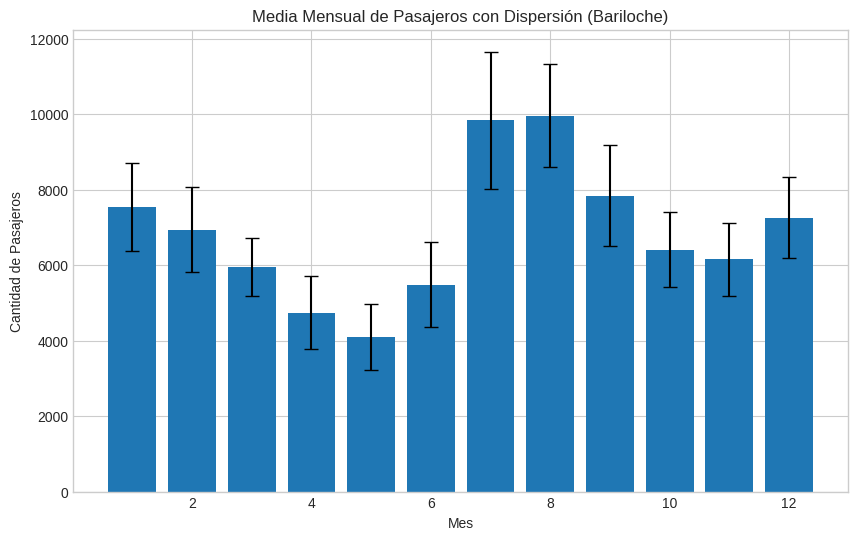

In [57]:
#  Promedio de pasajeros diarios por mes en Bariloche 

# Sumar todos los pasajeros que llegaron en cada fecha
# Resultado: una fila por día con el total de pasajeros de ese día
pasajeros_por_dia = bariloche.groupby(bariloche['Fecha UTC'].dt.date)['Pasajeros'].sum().reset_index()
pasajeros_por_dia.columns = ['Fecha', 'Total_Pasajeros_Dia']

# Extraer el mes de cada fecha para poder agrupar mensualmente
pasajeros_por_dia['Fecha'] = pd.to_datetime(pasajeros_por_dia['Fecha'])
pasajeros_por_dia['Mes']   = pasajeros_por_dia['Fecha'].dt.month

# Calcular la media y desvío estándar de los totales diarios agrupados por mes
informe_municipal_diario = (
    pasajeros_por_dia
    .groupby('Mes')['Total_Pasajeros_Dia']
    .agg(['mean', 'std'])
    .reset_index()
)
informe_municipal_diario.columns = ['Mes', 'Media_Pasajeros_Diarios', 'Desvio_Estandar_Diario']

print("--- Número promedio de pasajeros diarios por mes ---")
print(informe_municipal_diario)

# Gráfico de barras con barras de error para visualizar la variabilidad mensual
plt.figure(figsize=(10, 6))
plt.bar(
    informe_municipal_diario['Mes'],
    informe_municipal_diario['Media_Pasajeros_Diarios'],
    yerr=informe_municipal_diario['Desvio_Estandar_Diario'],
    capsize=5
)
plt.title('Media Mensual de Pasajeros con Dispersión (Bariloche)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Pasajeros')
plt.show()


In [58]:
mes_max = informe_municipal_diario.loc[
    informe_municipal_diario['Media_Pasajeros_Diarios'].idxmax()
]

In [59]:
print(
    f"Agosto es el pico máximo con el mayor promedio diario de pasajeros: "
    f"{mes_max['Media_Pasajeros_Diarios']:.0f}. "
    f"Al ser el desvío estándar superior a 1331, "
    f"es necesario considerar que pueden recibir algunos días más de "
    f"11.000 pasajeros."
)

Agosto es el pico máximo con el mayor promedio diario de pasajeros: 9958. Al ser el desvío estándar superior a 1331, es necesario considerar que pueden recibir algunos días más de 11.000 pasajeros.


## JULIO / AGOSTO vs MAYO: ¿Cómo varía el comportamiento?


 Comparación horaria: Mayo vs Invierno/Verano 
    Hora  Promedio_Mayo  Promedio_Invierno  Promedio_Verano  Diferencia Mayo Invierno  Incremento_%
0      0          205.0              308.0            264.0                     103.0          50.0
1      1          209.0              259.0            224.0                      51.0          24.0
2      2          200.0              220.0            173.0                      20.0          10.0
3      3          138.0              233.0            171.0                      95.0          69.0
4      4          147.0              162.0            160.0                      15.0          10.0
5      5          157.0              177.0            152.0                      20.0          13.0
6      6          158.0              184.0            176.0                      26.0          16.0
7      7          160.0              168.0            136.0                       7.0           5.0
8      8           94.0              143.0          

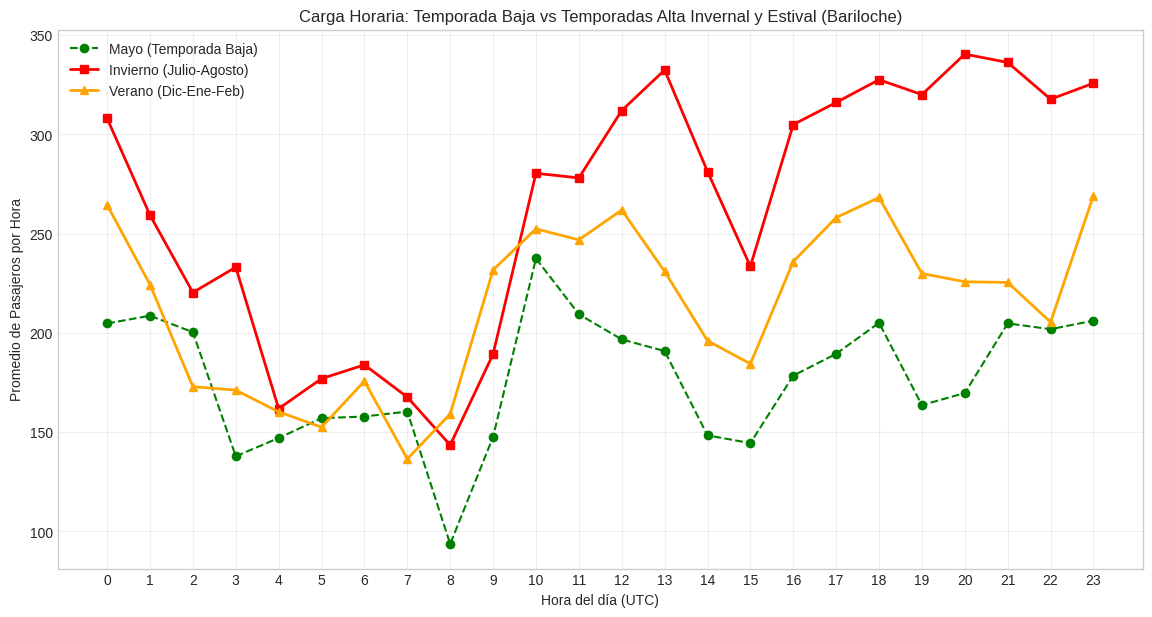

In [60]:
#  Análisis de carga horaria: temporada alta (agosto) vs. baja (mayo) 
# Extraer la hora
anac['hora'] = pd.to_datetime(anac['Hora UTC'], format='%H:%M').dt.hour

# Filtros
filtro_base = (
    (anac['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac['Aeropuerto'] == 'BAR')
)

df_mayo = anac.loc[
    filtro_base &
    (anac['mes'] == 5)
]

df_invierno = anac.loc[
    filtro_base &
    (anac['mes'].isin([7, 8]))
]

df_verano = anac.loc[
    filtro_base &
    (anac['mes'].isin([12, 1, 2]))
]
def obtener_promedio_horario(df):
    pax_dia_hora = (
        df.groupby(['Fecha UTC', 'hora'])['Pasajeros']
        .sum()
        .reset_index()
    )

    return (
        pax_dia_hora
        .groupby('hora')['Pasajeros']
        .mean()
        .reset_index()
    )

promedio_mayo = obtener_promedio_horario(df_mayo)
promedio_invierno = obtener_promedio_horario(df_invierno)
promedio_verano = obtener_promedio_horario(df_verano)

# TABLA COMPARATIVA
tabla_comparativa = (
    promedio_mayo
    .merge(
        promedio_invierno,
        on='hora',
        suffixes=('_Mayo', '_Invierno')
    )
    .merge(
        promedio_verano,
        on='hora'
    )
)

tabla_comparativa.columns = [
    'Hora',
    'Promedio_Mayo',
    'Promedio_Invierno',
    'Promedio_Verano'
]
tabla_comparativa['Diferencia Mayo Invierno'] = (
    tabla_comparativa['Promedio_Invierno']
    - tabla_comparativa['Promedio_Mayo']
)

tabla_comparativa['Incremento_%'] = (
    tabla_comparativa['Diferencia Mayo Invierno']
    / tabla_comparativa['Promedio_Mayo']
    * 100
)

print("\n Comparación horaria: Mayo vs Invierno/Verano ")
print(tabla_comparativa.round(0))

# GRÁFICO
plt.figure(figsize=(14, 7))

plt.plot(
    promedio_mayo['hora'],
    promedio_mayo['Pasajeros'],
    label='Mayo (Temporada Baja)',
    color='green',
    marker='o',
    linestyle='--'
)

plt.plot(
    promedio_invierno['hora'],
    promedio_invierno['Pasajeros'],
    label='Invierno (Julio-Agosto)',
    color='red',
    marker='s',
    linewidth=2
)

plt.plot(
    promedio_verano['hora'],
    promedio_verano['Pasajeros'],
    label='Verano (Dic-Ene-Feb)',
    color='orange',
    marker='^',
    linewidth=2
)

plt.xticks(range(24))
plt.xlabel('Hora del día (UTC)')
plt.ylabel('Promedio de Pasajeros por Hora')
plt.title('Carga Horaria: Temporada Baja vs Temporadas Alta Invernal y Estival (Bariloche)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Durante la temporada invernal (julio-agosto), el aeropuerto recibe aproximadamente 330 pasajeros por hora en los momentos de mayor demanda. Las franjas más exigentes se concentran entre las 12:00 y las 23:00 UTC, alcanzando un máximo de 340 pasajeros promedio por hora a las 20:00 UTC. En comparación con mayo, el incremento de pasajeros es especialmente significativo durante la tarde y la noche, llegando incluso a duplicar la demanda en algunas franjas horarias. El caso más destacado se observa a las 20:00 UTC, donde el volumen aumenta un 101% respecto de la temporada baja. Esta situación justifica reforzar la disponibilidad de transporte terrestre, servicios turísticos, personal operativo y capacidad de atención durante gran parte de la jornada.

Las franjas de menor actividad se concentran entre las 04:00 y las 08:00 UTC, registrándose el mínimo absoluto a las 08:00 UTC con un promedio de 143 pasajeros durante la temporada invernal. Sin embargo, incluso en esta hora de menor demanda, el volumen de pasajeros supera en un 53% al observado en mayo, lo que evidencia que la actividad aeroportuaria se mantiene elevada durante todo el período turístico.

La temporada de verano presenta un comportamiento intermedio entre mayo e invierno, con picos relevantes en horas del mediodía, a las 18 y a las 23. Se observa un incremento sostenido respecto a mayo entre las 08:00 y 13:00 UTC, las 16:00 y 19:00 y 22:00 y 00:00 con un máximo cercano a las 268 pasajeros por hora a las 18:00 UTC.

Si bien el verano no alcanza los niveles del invierno en horas punta, sí mantiene una demanda elevada y más distribuida a lo largo del día, lo que sugiere una operación menos concentrada pero más constante.

## En invierno, ¿Qué día de la semana recibe más pasajeros?

  dia_semana  Pasajeros
0      Lunes     4739.0
1     Martes     4698.0
2  Miércoles     4572.0
3     Jueves     5060.0
4    Viernes     4981.0
5     Sábado     5938.0
6    Domingo     4939.0


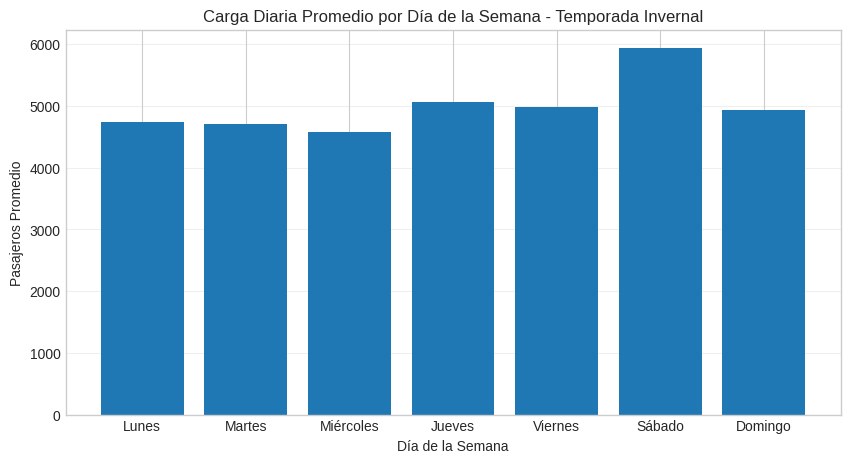

In [61]:
# Distribución semanal de pasajeros en Bariloche durante Agosto 
# Sumar pasajeros por fecha
pax_diarios_invierno = (
    df_invierno
    .groupby('Fecha UTC')['Pasajeros']
    .sum()
    .reset_index()
)

# Obtener día de la semana
pax_diarios_invierno['dia_semana'] = (
    pax_diarios_invierno['Fecha UTC']
    .dt.day_name()
)

# Orden de días
orden_dias = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Promedio por día de la semana
promedio_invierno_semanal = (
    pax_diarios_invierno
    .groupby('dia_semana')['Pasajeros']
    .mean()
    .reindex(orden_dias)
    .reset_index()
)

# Traducir
promedio_invierno_semanal['dia_semana'] = (
    promedio_invierno_semanal['dia_semana']
    .map(DIAS)
)

print(promedio_invierno_semanal.round(0))

plt.figure(figsize=(10, 5))

plt.bar(
    promedio_invierno_semanal['dia_semana'],
    promedio_invierno_semanal['Pasajeros']
)

plt.title('Carga Diaria Promedio por Día de la Semana - Temporada Invernal')
plt.ylabel('Pasajeros Promedio')
plt.xlabel('Día de la Semana')
plt.grid(axis='y', alpha=0.3)

plt.show()

El análisis de la distribución semanal durante la temporada invernal evidencia una marcada concentración de pasajeros hacia el fin de semana. Los sábados constituyen el día de mayor demanda, con un promedio de 5.938 pasajeros, mientras que los miércoles registran el menor volumen, con 4.572 pasajeros. La diferencia entre ambos extremos alcanza aproximadamente 1.366 pasajeros diarios, lo que representa una variación cercana al 30%. Asimismo, se observa un incremento gradual de la actividad a partir del jueves, alcanzando su máximo durante el sábado. 

## Modelo normal: aterrizajes diarios durante agosto

### Pregunta de análisis

> Suponiendo que la cantidad diaria de pasajeros que aterrizan en Bariloche durante agosto puede aproximarse mediante una distribución normal, ¿cuál es la probabilidad de que la demanda diaria se encuentre dentro de un desvío estándar respecto de la media?

### ¿Por qué se analiza agosto?

Agosto fue seleccionado porque el análisis descriptivo previo lo identifica como el mes con mayor demanda promedio en el aeropuerto de Bariloche. Además, corresponde a la temporada invernal, uno de los períodos turísticos más importantes para la ciudad.

No se utilizan todos los meses juntos porque la demanda presenta una marcada estacionalidad. Mezclar temporada alta y temporada baja produciría una población heterogénea, cuya media y desvío estándar podrían no representar correctamente ningún período particular.

Se analizan los meses de agosto de 2023, 2024 y 2025. Esto permite disponer de una cantidad mayor de observaciones que si se utilizara un único año y evita incluir 2026, cuyos datos están disponibles solamente hasta abril.

En este análisis se consideran únicamente los **aterrizajes**, ya que el objetivo es estudiar la cantidad de pasajeros que efectivamente llegan al destino. Esta información puede utilizarse para planificar transporte terrestre, personal, atención aeroportuaria y servicios turísticos.

Se emplea el intervalo comprendido entre la media menos un desvío estándar y la media más un desvío estándar. En una distribución normal teórica, aproximadamente el 68,27% de las observaciones debería encontrarse dentro de ese intervalo. Este resultado se comparará con la frecuencia observada en los datos reales.

,Indicador,Valor
0,Cantidad de días analizados,93.0000
1,Media diaria,4846.8817
2,Desvío estándar,714.7042
3,Límite inferior,4132.1776
4,Límite superior,5561.5859
5,Probabilidad normal,0.6827
6,Frecuencia empírica,0.6667


Días analizados: 93
Media diaria: 4847 pasajeros
Desvío estándar: 715 pasajeros
Intervalo analizado: entre 4132 y 5562 pasajeros
Probabilidad según el modelo normal: 68.27%
Frecuencia observada en los datos reales: 66.67%


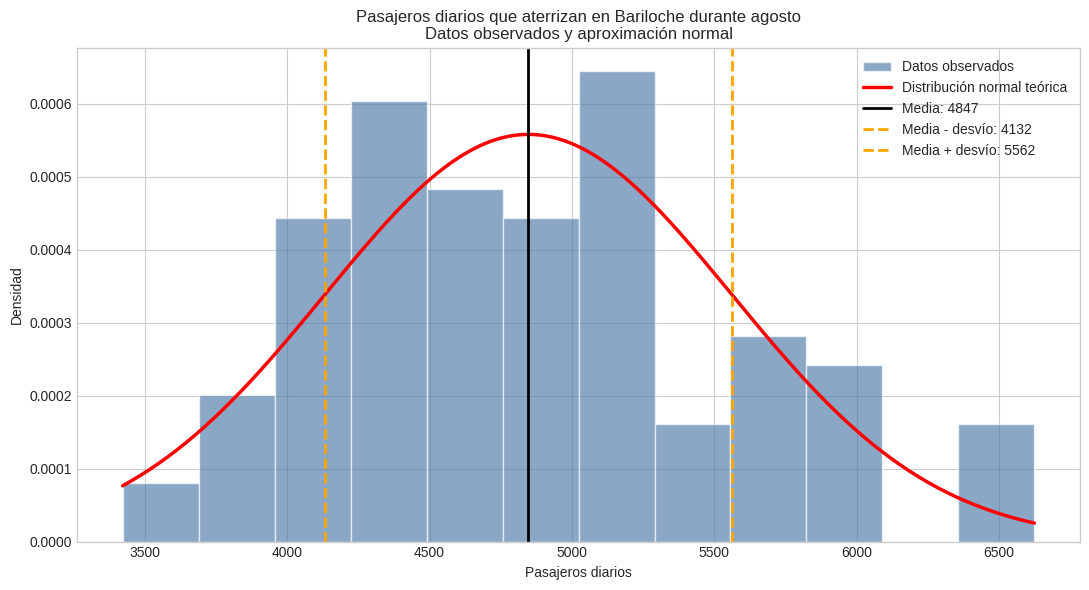

In [62]:
aterrizajes_agosto = anac[
    (anac['Aeropuerto'] == 'BAR') &
    (anac['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac['anio'].isin([2023, 2024, 2025])) &
    (anac['mes'] == 8)
].copy()

# Total de pasajeros que aterrizaron en Bariloche en cada fecha
pasajeros_diarios_agosto = (
    aterrizajes_agosto
    .groupby('Fecha UTC')['Pasajeros']
    .sum()
    .sort_index()
)

# Parámetros estimados a partir de los datos
media_agosto = pasajeros_diarios_agosto.mean()
desvio_agosto = pasajeros_diarios_agosto.std()

# Intervalo de un desvío estándar alrededor de la media
limite_inferior = media_agosto - desvio_agosto
limite_superior = media_agosto + desvio_agosto

# Probabilidad según el modelo normal
probabilidad_normal = (
    norm.cdf(limite_superior, loc=media_agosto, scale=desvio_agosto)
    - norm.cdf(limite_inferior, loc=media_agosto, scale=desvio_agosto)
)

# Frecuencia observada realmente en el dataset
frecuencia_empirica = pasajeros_diarios_agosto.between(
    limite_inferior,
    limite_superior
).mean()

resumen_normal = pd.DataFrame({
    'Indicador': [
        'Cantidad de días analizados',
        'Media diaria',
        'Desvío estándar',
        'Límite inferior',
        'Límite superior',
        'Probabilidad normal',
        'Frecuencia empírica'
    ],
    'Valor': [
        len(pasajeros_diarios_agosto),
        media_agosto,
        desvio_agosto,
        limite_inferior,
        limite_superior,
        probabilidad_normal,
        frecuencia_empirica
    ]
})

display(resumen_normal.round(4))

print(f"Días analizados: {len(pasajeros_diarios_agosto)}")
print(f"Media diaria: {media_agosto:.0f} pasajeros")
print(f"Desvío estándar: {desvio_agosto:.0f} pasajeros")
print(
    f"Intervalo analizado: entre {limite_inferior:.0f} "
    f"y {limite_superior:.0f} pasajeros"
)
print(
    f"Probabilidad según el modelo normal: "
    f"{probabilidad_normal * 100:.2f}%"
)
print(
    f"Frecuencia observada en los datos reales: "
    f"{frecuencia_empirica * 100:.2f}%"
)

# Histograma de los datos reales con curva normal superpuesta
x = np.linspace(
    pasajeros_diarios_agosto.min(),
    pasajeros_diarios_agosto.max(),
    300
)

densidad_normal = norm.pdf(
    x,
    loc=media_agosto,
    scale=desvio_agosto
)

plt.figure(figsize=(11, 6))

plt.hist(
    pasajeros_diarios_agosto,
    bins=12,
    density=True,
    alpha=0.65,
    color='#4c78a8',
    edgecolor='white',
    label='Datos observados'
)

plt.plot(
    x,
    densidad_normal,
    color='red',
    linewidth=2.5,
    label='Distribución normal teórica'
)

plt.axvline(
    media_agosto,
    color='black',
    linewidth=2,
    label=f'Media: {media_agosto:.0f}'
)

plt.axvline(
    limite_inferior,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'Media - desvío: {limite_inferior:.0f}'
)

plt.axvline(
    limite_superior,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'Media + desvío: {limite_superior:.0f}'
)

plt.title(
    'Pasajeros diarios que aterrizan en Bariloche durante agosto\n'
    'Datos observados y aproximación normal'
)
plt.xlabel('Pasajeros diarios')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación del modelo normal

El modelo normal estima que aproximadamente el **68,27%** de los días debería registrar una cantidad de pasajeros comprendida entre la media menos un desvío estándar y la media más un desvío estándar.

Esta probabilidad teórica se compara con la frecuencia empírica, es decir, con el porcentaje de días del dataset que efectivamente se encuentra dentro del mismo intervalo.

Si ambos porcentajes son cercanos y el histograma presenta una forma aproximadamente simétrica alrededor de la media, la distribución normal puede considerarse una aproximación razonable para describir la demanda diaria durante agosto.

Si existe una diferencia importante entre ambos resultados, o si el histograma presenta asimetrías, varios picos o valores extremos, debe concluirse que la distribución normal tiene limitaciones para representar estos datos. El objetivo no es forzar el ajuste, sino comprobar si el modelo teórico describe adecuadamente la evidencia observada.

Desde el punto de vista operativo, el intervalo calculado representa el rango habitual de pasajeros diarios durante la temporada invernal. Esto puede ayudar a dimensionar personal, transporte terrestre y servicios aeroportuarios. Los días que superen el límite superior pueden considerarse escenarios de demanda especialmente alta que requieren una planificación adicional.

## ¿Qué probabilidades pueden estimarse con modelos binomial y Poisson?

- **Binomial:** ¿Cuál es la probabilidad de que, al seleccionar 10 movimientos al azar durante la temporada invernal, al menos 3 transporten más de 174 pasajeros?
- **Poisson:** ¿Cuál es la probabilidad de que, durante un día de la temporada invernal, se registren más de 10 movimientos de muy alta demanda?

In [63]:
#  Modelo Binomial: movimientos de muy alta demanda durante el invierno 

# Definir el umbral de "muy alta demanda" utilizando el percentil 75. Por que?
# Esto significa que solo el 25% de los movimientos tienen más pasajeros
# que este valor.
umbral_alto = df_invierno['Pasajeros'].quantile(0.75)

print(f"Umbral de muy alta demanda: {umbral_alto:.0f} pasajeros")

# Calcular la probabilidad de que un movimiento supere dicho umbral.
# Esta será la probabilidad de éxito (p) del modelo binomial.
p_alta_demanda = (
    df_invierno['Pasajeros'] > umbral_alto
).mean()

print(f"p = {p_alta_demanda:.3f}")

# Definir los parámetros del experimento.
# Se seleccionan 10 movimientos al azar y se desea conocer la probabilidad
# de que al menos 3 sean de muy alta demanda.
n = 10
k_min = 3

# Calcular P(X ≥ 3) utilizando la distribución binomial.
# Se suman las probabilidades de obtener 3, 4, ..., 10 movimientos
# de muy alta demanda.
prob_binomial_al_menos_3 = sum(
    comb(n, k) * (p_alta_demanda ** k) * ((1 - p_alta_demanda) ** (n - k))
    for k in range(k_min, n + 1)
)

# Mostrar resultados.
print(
    f"Probabilidad de que al menos 3 de 10 movimientos "
    f"sean de muy alta demanda "
)

print(
    f"Porcentaje: {prob_binomial_al_menos_3 * 100:.2f}%"
)

Umbral de muy alta demanda: 174 pasajeros
p = 0.244
Probabilidad de que al menos 3 de 10 movimientos sean de muy alta demanda 
Porcentaje: 45.75%


Se definió como movimiento de muy alta demanda a aquel que transporta más de 174 pasajeros, valor correspondiente al percentil 75 de la distribución de pasajeros durante la temporada invernal. Esto implica que aproximadamente el 24,4% de los movimientos observados supera dicho umbral.

Mediante un modelo binomial se estimó la probabilidad de que, al seleccionar 10 movimientos al azar durante el invierno, al menos 3 correspondan a esta categoría. El resultado obtenido fue del 45,75%, lo que indica que la presencia de movimientos de muy alta demanda es relativamente frecuente durante la temporada turística.


In [64]:
# Modelo de Poisson: movimientos de muy alta demanda por día

# Definir el umbral de muy alta demanda.
# Se utiliza el percentil 75 de pasajeros de la temporada invernal.
umbral_alto = df_invierno['Pasajeros'].quantile(0.75)

# Identificar los movimientos que superan dicho umbral.
movimientos_altos = df_invierno[
    df_invierno['Pasajeros'] > umbral_alto
]

# Contar cuántos movimientos de muy alta demanda ocurren cada día.
altos_por_dia = (
    movimientos_altos
    .groupby('Fecha UTC')
    .size()
    .reset_index(name='Movimientos_Alta_Demanda')
)

# Calcular λ (lambda), es decir,
# el número promedio diario de movimientos de muy alta demanda.
lambda_poisson = altos_por_dia['Movimientos_Alta_Demanda'].mean()

print(f"Umbral de muy alta demanda: {umbral_alto:.0f} pasajeros")
print(
    f"Promedio diario de movimientos de muy alta demanda (λ): "
    f"{lambda_poisson:.2f}"
)

# Calcular la probabilidad de observar más de 10 movimientos
# de muy alta demanda en un día cualquiera de la temporada invernal.
x = 10

prob_mas_de_10 = 1 - poisson.cdf(x, lambda_poisson)

print(
    f"\nProbabilidad de que un día registre más de {x} "
    f"movimientos de muy alta demanda:"
)
print(f"{prob_mas_de_10:.4f}")
print(f"{prob_mas_de_10 * 100:.2f}%")

Umbral de muy alta demanda: 174 pasajeros
Promedio diario de movimientos de muy alta demanda (λ): 8.27

Probabilidad de que un día registre más de 10 movimientos de muy alta demanda:
0.2122
21.22%


El análisis mediante un modelo de Poisson indica que durante la temporada invernal se producen, en promedio, 8,27 movimientos diarios de muy alta demanda, definidos como aquellos que transportan más de 174 pasajeros. A partir de este promedio, se estimó una probabilidad del 21,22% de que en un día cualquiera se registren más de 10 movimientos de esta categoría.

## Parte predictiva: feriados largos y demanda en Bariloche

Aclaración: en esta sección predictiva se trabaja específicamente con los aterrizajes en el aeropuerto de Bariloche, ya que el objetivo es estimar la llegada de pasajeros al destino turístico. Por este motivo, los valores utilizados en el modelo pueden diferir de otros apartados del trabajo donde se consideran todos los movimientos aeroportuarios, incluyendo aterrizajes y despegues.

In [65]:
# Nos quedamos solo con Bariloche y con aterrizajes
# Usamos aterrizajes porque representan la llegada de pasajeros al destino turístico.

bariloche_aterrizajes = anac[
    (anac['Aeropuerto'] == 'BAR') &
    (anac['Tipo de Movimiento'] == 'Aterrizaje')
].copy()

# Aseguramos que la fecha esté en formato datetime
bariloche_aterrizajes['Fecha UTC'] = pd.to_datetime(bariloche_aterrizajes['Fecha UTC'])

# Agrupamos por día
# Para cada fecha calculamos:
# - cantidad total de pasajeros
# - cantidad de vuelos/movimientos
# - promedio de pasajeros por vuelo

datos_diarios = (
    bariloche_aterrizajes
    .groupby('Fecha UTC')
    .agg(
        pasajeros_totales=('Pasajeros', 'sum'),
        cantidad_vuelos=('Pasajeros', 'count'),
        pasajeros_promedio_por_vuelo=('Pasajeros', 'mean')
    )
    .reset_index()
)

# Creamos variables de fecha
datos_diarios['anio'] = datos_diarios['Fecha UTC'].dt.year
datos_diarios['mes'] = datos_diarios['Fecha UTC'].dt.month
datos_diarios['dia'] = datos_diarios['Fecha UTC'].dt.day
datos_diarios['dia_semana_num'] = datos_diarios['Fecha UTC'].dt.dayofweek
# Lunes = 0, Martes = 1, ..., Domingo = 6

datos_diarios['es_fin_de_semana'] = datos_diarios['dia_semana_num'].isin([5, 6]).astype(int)

display(datos_diarios.head())

,Fecha UTC,pasajeros_totales,cantidad_vuelos,pasajeros_promedio_por_vuelo,anio,mes,dia,dia_semana_num,es_fin_de_semana
0,2023-01-01,2903.0,23,126.217391,2023,1,1,6,1
1,2023-01-02,3461.0,30,115.366667,2023,1,2,0,0
2,2023-01-03,3600.0,27,133.333333,2023,1,3,1,0
3,2023-01-04,4137.0,32,129.281250,2023,1,4,2,0
4,2023-01-05,3942.0,28,140.785714,2023,1,5,3,0


## Creamos la variable de feriado largo

In [66]:
# Lista ampliada de períodos considerados feriados, fines de semana largos
# o días no laborables turísticos en Argentina.
# Formato: desde, hasta
# Si el feriado fue de un solo día, inicio y fin son iguales.

feriados_largos = [
    # 2023
    ('2023-01-01', '2023-01-01'),  # Año Nuevo
    ('2023-02-18', '2023-02-21'),  # Carnaval
    ('2023-03-24', '2023-03-26'),  # Día de la Memoria
    ('2023-04-02', '2023-04-02'),  # Malvinas
    ('2023-04-06', '2023-04-09'),  # Jueves Santo + Viernes Santo + Semana Santa
    ('2023-04-29', '2023-05-01'),  # Día del Trabajador
    ('2023-05-25', '2023-05-28'),  # Revolución de Mayo + puente turístico
    ('2023-06-17', '2023-06-20'),  # Güemes + puente turístico + Belgrano
    ('2023-07-09', '2023-07-09'),  # Día de la Independencia
    ('2023-08-19', '2023-08-21'),  # San Martín trasladado
    ('2023-10-13', '2023-10-16'),  # Puente turístico + Diversidad Cultural trasladado
    ('2023-11-18', '2023-11-20'),  # Soberanía Nacional
    ('2023-12-08', '2023-12-10'),  # Inmaculada Concepción
    ('2023-12-23', '2023-12-25'),  # Navidad

    # 2024
    ('2024-01-01', '2024-01-01'),  # Año Nuevo
    ('2024-02-10', '2024-02-13'),  # Carnaval
    ('2024-03-24', '2024-03-24'),  # Día de la Memoria
    ('2024-03-28', '2024-04-02'),  # Semana Santa + puente turístico + Malvinas
    ('2024-05-01', '2024-05-01'),  # Día del Trabajador
    ('2024-05-25', '2024-05-26'),  # Revolución de Mayo
    ('2024-06-15', '2024-06-17'),  # Güemes
    ('2024-06-20', '2024-06-23'),  # Belgrano + puente turístico
    ('2024-07-09', '2024-07-09'),  # Día de la Independencia
    ('2024-08-17', '2024-08-18'),  # San Martín
    ('2024-10-11', '2024-10-13'),  # Puente turístico + Diversidad Cultural
    ('2024-11-16', '2024-11-18'),  # Soberanía Nacional
    ('2024-12-08', '2024-12-08'),  # Inmaculada Concepción
    ('2024-12-25', '2024-12-25'),  # Navidad

    # 2025
    ('2025-01-01', '2025-01-01'),  # Año Nuevo
    ('2025-03-01', '2025-03-04'),  # Carnaval
    ('2025-03-22', '2025-03-24'),  # Día de la Memoria
    ('2025-04-02', '2025-04-02'),  # Malvinas
    ('2025-04-17', '2025-04-20'),  # Jueves Santo + Viernes Santo + Semana Santa
    ('2025-05-01', '2025-05-04'),  # Día del Trabajador + puente turístico
    ('2025-05-25', '2025-05-25'),  # Revolución de Mayo
    ('2025-06-14', '2025-06-16'),  # Güemes trasladado
    ('2025-06-20', '2025-06-22'),  # Belgrano
    ('2025-07-09', '2025-07-09'),  # Día de la Independencia
    ('2025-08-15', '2025-08-17'),  # Puente turístico + San Martín
    ('2025-10-10', '2025-10-12'),  # Diversidad Cultural trasladado
    ('2025-11-21', '2025-11-24'),  # Puente turístico + Soberanía Nacional trasladado
    ('2025-12-06', '2025-12-08'),  # Inmaculada Concepción
    ('2025-12-25', '2025-12-25'),  # Navidad

    # 2026
    # Los dataset llegan a abril y mayo de 2026, los feriados posteriores
    # no afectan el resultado. Pero se dejan cargados igualmente.
    ('2026-01-01', '2026-01-04'),  # Año Nuevo
    ('2026-02-14', '2026-02-17'),  # Carnaval
    ('2026-03-21', '2026-03-24'),  # Puente turístico + Día de la Memoria
    ('2026-04-02', '2026-04-05'),  # Malvinas + Viernes Santo + Semana Santa
    ('2026-05-01', '2026-05-03'),  # Día del Trabajador
    ('2026-05-23', '2026-05-25'),  # Revolución de Mayo
    ('2026-06-13', '2026-06-15'),  # Güemes trasladado
    ('2026-06-20', '2026-06-21'),  # Belgrano
    ('2026-07-09', '2026-07-12'),  # Independencia + puente turístico
    ('2026-08-15', '2026-08-17'),  # San Martín
    ('2026-10-10', '2026-10-12'),  # Diversidad Cultural
    ('2026-11-21', '2026-11-23'),  # Soberanía Nacional
    ('2026-12-05', '2026-12-08'),  # Puente turístico + Inmaculada Concepción
    ('2026-12-25', '2026-12-25'),  # Navidad
]

# Función para identificar si una fecha pertenece a un feriado largo
def marcar_feriado_largo(fecha):
    for inicio, fin in feriados_largos:
        if pd.to_datetime(inicio) <= fecha <= pd.to_datetime(fin):
            return 1
    return 0

# Creamos la variable
datos_diarios['es_feriado_largo'] = datos_diarios['Fecha UTC'].apply(marcar_feriado_largo)
print("Cantidad de días marcados como feriado o fin de semana largo:")
print(datos_diarios['es_feriado_largo'].value_counts())

display(
    datos_diarios[datos_diarios['es_feriado_largo'] == 1]
    [['Fecha UTC', 'pasajeros_totales', 'cantidad_vuelos']]
    .head(20)
)

Cantidad de días marcados como feriado o fin de semana largo:
es_feriado_largo
0    1084
1     129
Name: count, dtype: int64


,Fecha UTC,pasajeros_totales,cantidad_vuelos
0,2023-01-01,2903.0,23
48,2023-02-18,4103.0,29
49,2023-02-19,3858.0,26
50,2023-02-20,3095.0,20
51,2023-02-21,2611.0,32
82,2023-03-24,2781.0,23
83,2023-03-25,2661.0,28
84,2023-03-26,2839.0,29
91,2023-04-02,3244.0,26
95,2023-04-06,3267.0,27


La variable `es_feriado_largo` identifica fechas correspondientes a feriados nacionales, fines de semana largos y días no laborables con fines turísticos dentro del período analizado. Se incluyeron tanto períodos de varios días como feriados de un solo día, debido a que ambos pueden afectar la demanda turística y el movimiento de pasajeros hacia Bariloche.

In [67]:
comparacion_feriados = (
    datos_diarios
    .groupby('es_feriado_largo')
    .agg(
        dias_analizados=('Fecha UTC', 'count'),
        promedio_pasajeros=('pasajeros_totales', 'mean'),
        promedio_vuelos=('cantidad_vuelos', 'mean'),
        promedio_pasajeros_por_vuelo=('pasajeros_promedio_por_vuelo', 'mean')
    )
    .reset_index()
)

comparacion_feriados['tipo_dia'] = comparacion_feriados['es_feriado_largo'].map({
    0: 'Día normal',
    1: 'Feriado largo'
})

display(comparacion_feriados)

,es_feriado_largo,dias_analizados,promedio_pasajeros,promedio_vuelos,promedio_pasajeros_por_vuelo,tipo_dia
0,0,1084,3387.785055,25.26476,135.134370,Día normal
1,1,129,3369.581395,25.24031,134.731874,Feriado largo


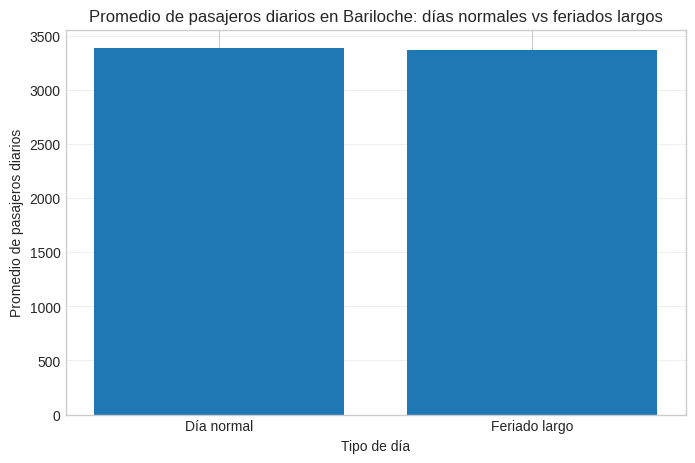

In [68]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparacion_feriados['tipo_dia'],
    comparacion_feriados['promedio_pasajeros']
)

plt.title('Promedio de pasajeros diarios en Bariloche: días normales vs feriados largos')
plt.xlabel('Tipo de día')
plt.ylabel('Promedio de pasajeros diarios')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [69]:
# Variables predictoras
X = datos_diarios[
    [
        'mes',
        'dia_semana_num',
        'es_fin_de_semana',
        'es_feriado_largo',
        'cantidad_vuelos'
    ]
]

# Variable objetivo
y = datos_diarios['pasajeros_totales']

# Dividimos datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Creamos el modelo
modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Entrenamos el modelo
modelo.fit(X_train, y_train)

# Hacemos predicciones
y_pred = modelo.predict(X_test)

# Evaluamos el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo predictivo")
print("--------------------------------")
print(f"Error absoluto medio MAE: {mae:.2f} pasajeros")
print(f"R2 del modelo: {r2:.2f}")

Evaluación del modelo predictivo
--------------------------------
Error absoluto medio MAE: 326.41 pasajeros
R2 del modelo: 0.86


,variable,importancia
4,cantidad_vuelos,0.799479
0,mes,0.155860
1,dia_semana_num,0.033064
3,es_feriado_largo,0.006601
2,es_fin_de_semana,0.004996


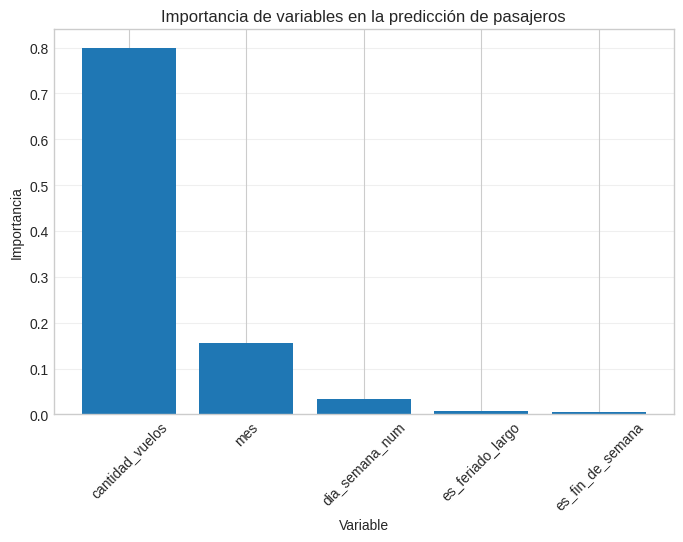

In [70]:
importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': modelo.feature_importances_
}).sort_values(by='importancia', ascending=False)

display(importancias)

plt.figure(figsize=(8, 5))

plt.bar(
    importancias['variable'],
    importancias['importancia']
)

plt.title('Importancia de variables en la predicción de pasajeros')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

## Ejemplos de predicciones para días específicos

In [71]:
#Simulación de un escenario futuro
# Ejemplo: julio, sábado, feriado largo, con 35 vuelos estimados

nuevo_escenario = pd.DataFrame({
    'mes': [7],
    'dia_semana_num': [5],       # sábado
    'es_fin_de_semana': [1],
    'es_feriado_largo': [1],
    'cantidad_vuelos': [35]
})

prediccion_pasajeros = modelo.predict(nuevo_escenario)

print("Predicción para escenario de feriado largo")
print(f"Pasajeros diarios estimados: {prediccion_pasajeros[0]:.0f}")

Predicción para escenario de feriado largo
Pasajeros diarios estimados: 4947


In [72]:
escenario_normal = pd.DataFrame({
    'mes': [7],
    'dia_semana_num': [2],       # miércoles
    'es_fin_de_semana': [0],
    'es_feriado_largo': [0],
    'cantidad_vuelos': [25]
})

prediccion_normal = modelo.predict(escenario_normal)

print("Comparación predictiva")
print(f"Día normal estimado: {prediccion_normal[0]:.0f} pasajeros")
print(f"Feriado largo estimado: {prediccion_pasajeros[0]:.0f} pasajeros")

diferencia = prediccion_pasajeros[0] - prediccion_normal[0]
porcentaje = diferencia / prediccion_normal[0] * 100

print(f"Diferencia estimada: {diferencia:.0f} pasajeros")
print(f"Incremento estimado: {porcentaje:.2f}%")

Comparación predictiva
Día normal estimado: 3624 pasajeros
Feriado largo estimado: 4947 pasajeros
Diferencia estimada: 1323 pasajeros
Incremento estimado: 36.51%


Para la parte predictiva se construyeron dos modelos que estiman la cantidad diaria de pasajeros que arriban al aeropuerto de Bariloche. Para ello se utilizaron variables temporales como el mes, el día de la semana, si corresponde a fin de semana y si pertenece a un feriado largo. También se incorporó la cantidad de vuelos diarios como indicador de actividad aeroportuaria.

La variable es_feriado_largo permite identificar períodos de mayor movimiento turístico. A partir de esta variable, el modelo puede comparar días normales con fines de semana largos y estimar el posible incremento de pasajeros.

Esta predicción resulta útil para la empresa u organismo solicitante porque permite anticipar escenarios de alta demanda, reforzar personal, coordinar transporte público y traslados turísticos, y mejorar la planificación operativa del aeropuerto durante fechas críticas.

## Modelo Alternativo

En el modelo predictivo, la variable con mayor importancia fue la cantidad de vuelos diarios, lo cual indica que el volumen de pasajeros depende principalmente de la cantidad de vuelos programados. La variable feriado largo tuvo una incidencia menor, ya que en los datos analizados no se observa una diferencia muy marcada entre el promedio de pasajeros de días normales y feriados largos.

In [73]:
# Modelo alternativo sin cantidad_vuelos
# Este modelo sirve para ver mejor el efecto de las variables de calendario,
# como mes, día de semana, fin de semana y feriado largo.

X_calendario = datos_diarios[
    [
        'mes',
        'dia_semana_num',
        'es_fin_de_semana',
        'es_feriado_largo'
    ]
]

y = datos_diarios['pasajeros_totales']

X_train, X_test, y_train, y_test = train_test_split(
    X_calendario,
    y,
    test_size=0.2,
    random_state=42
)

modelo_calendario = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_calendario.fit(X_train, y_train)

y_pred = modelo_calendario.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo predictivo sin cantidad de vuelos")
print(f"Error absoluto medio MAE: {mae:.2f} pasajeros")
print(f"R2 del modelo: {r2:.2f}")

Evaluación del modelo predictivo sin cantidad de vuelos
Error absoluto medio MAE: 445.71 pasajeros
R2 del modelo: 0.72


,variable,importancia
0,mes,0.861827
1,dia_semana_num,0.097446
2,es_fin_de_semana,0.020968
3,es_feriado_largo,0.019759


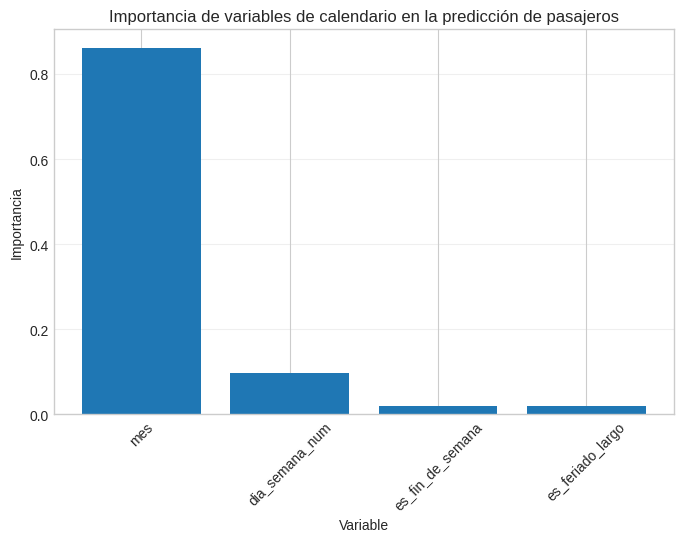

In [74]:
importancias_calendario = pd.DataFrame({
    'variable': X_calendario.columns,
    'importancia': modelo_calendario.feature_importances_
}).sort_values(by='importancia', ascending=False)

display(importancias_calendario)

plt.figure(figsize=(8, 5))

plt.bar(
    importancias_calendario['variable'],
    importancias_calendario['importancia']
)

plt.title('Importancia de variables de calendario en la predicción de pasajeros')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

El primer modelo incluyó la cantidad de vuelos diarios y mostró que esta variable es la principal explicación del volumen de pasajeros. Luego se realizó un segundo modelo sin la variable cantidad de vuelos, con el objetivo de observar mejor el efecto de las variables de calendario, como el mes, el día de la semana, el fin de semana y los feriados largos.

El modelo predictivo sin la variable cantidad de vuelos obtuvo un R2 de 0.73, lo que indica una capacidad aceptable para estimar la cantidad diaria de pasajeros a partir de variables de calendario.

La variable más importante fue el mes, lo cual resulta coherente con el comportamiento turístico de Bariloche, ya que la demanda aérea varía fuertemente según la temporada del año. En cambio, la variable feriado largo tuvo una importancia menor, lo que sugiere que los fines de semana largos influyen en la demanda, pero no tanto como la estacionalidad mensual.

## Comparación entre valores reales y valores predichos

In [75]:

comparacion_predicciones = pd.DataFrame({
    'pasajeros_reales': y_test.values,
    'pasajeros_predichos': y_pred
})

comparacion_predicciones['diferencia'] = (
    comparacion_predicciones['pasajeros_reales'] - comparacion_predicciones['pasajeros_predichos']
)

display(comparacion_predicciones.head(10))

,pasajeros_reales,pasajeros_predichos,diferencia
0,3545.0,3860.265585,-315.265585
1,3260.0,3109.854234,150.145766
2,3476.0,3306.812240,169.187760
3,2443.0,2523.460250,-80.460250
4,1897.0,2279.359064,-382.359064
5,5275.0,4694.095670,580.904330
6,3649.0,4174.622537,-525.622537
7,4417.0,4755.860928,-338.860928
8,2223.0,1813.173900,409.826100
9,1655.0,2362.029600,-707.029600


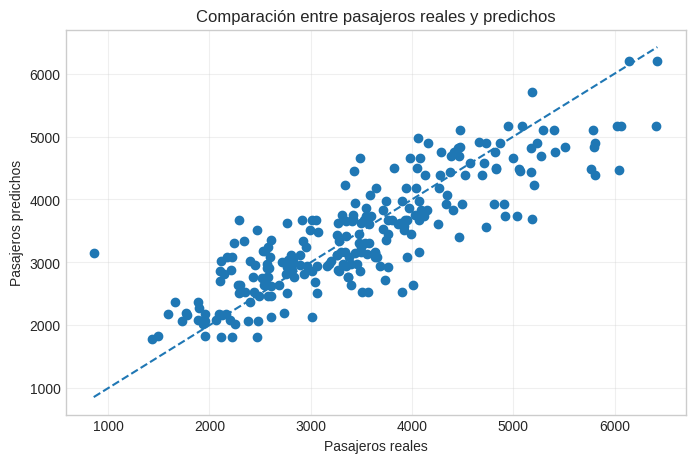

In [76]:
plt.figure(figsize=(8, 5))

plt.scatter(
    comparacion_predicciones['pasajeros_reales'],
    comparacion_predicciones['pasajeros_predichos']
)

# Línea de referencia: predicción perfecta
min_val = min(
    comparacion_predicciones['pasajeros_reales'].min(),
    comparacion_predicciones['pasajeros_predichos'].min()
)

max_val = max(
    comparacion_predicciones['pasajeros_reales'].max(),
    comparacion_predicciones['pasajeros_predichos'].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.title('Comparación entre pasajeros reales y predichos')
plt.xlabel('Pasajeros reales')
plt.ylabel('Pasajeros predichos')
plt.grid(alpha=0.3)

plt.show()

La línea diagonal representa una predicción perfecta. Los puntos cercanos a esa línea indican predicciones más precisas, mientras que los puntos alejados muestran una mayor diferencia entre el valor real y el valor estimado.

In [77]:
# Creamos una columna para clasificar días de alta demanda

umbral_alta_demanda = datos_diarios['pasajeros_totales'].quantile(0.75)

datos_diarios['alta_demanda'] = np.where(
    datos_diarios['pasajeros_totales'] >= umbral_alta_demanda,
    1,
    0
)

print(f"Umbral de alta demanda: {umbral_alta_demanda:.0f} pasajeros diarios")

display(datos_diarios[['Fecha UTC', 'pasajeros_totales', 'alta_demanda']].head())

Umbral de alta demanda: 4011 pasajeros diarios


,Fecha UTC,pasajeros_totales,alta_demanda
0,2023-01-01,2903.0,0
1,2023-01-02,3461.0,0
2,2023-01-03,3600.0,0
3,2023-01-04,4137.0,1
4,2023-01-05,3942.0,0


In [78]:
alta_demanda_feriados = (
    datos_diarios
    .groupby('es_feriado_largo')
    .agg(
        cantidad_dias=('Fecha UTC', 'count'),
        dias_alta_demanda=('alta_demanda', 'sum'),
        porcentaje_alta_demanda=('alta_demanda', 'mean')
    )
    .reset_index()
)

alta_demanda_feriados['porcentaje_alta_demanda'] = (
    alta_demanda_feriados['porcentaje_alta_demanda'] * 100
)

alta_demanda_feriados['tipo_dia'] = alta_demanda_feriados['es_feriado_largo'].map({
    0: 'Día normal',
    1: 'Feriado largo'
})

display(alta_demanda_feriados)

,es_feriado_largo,cantidad_dias,dias_alta_demanda,porcentaje_alta_demanda,tipo_dia
0,0,1084,278,25.645756,Día normal
1,1,129,26,20.155039,Feriado largo


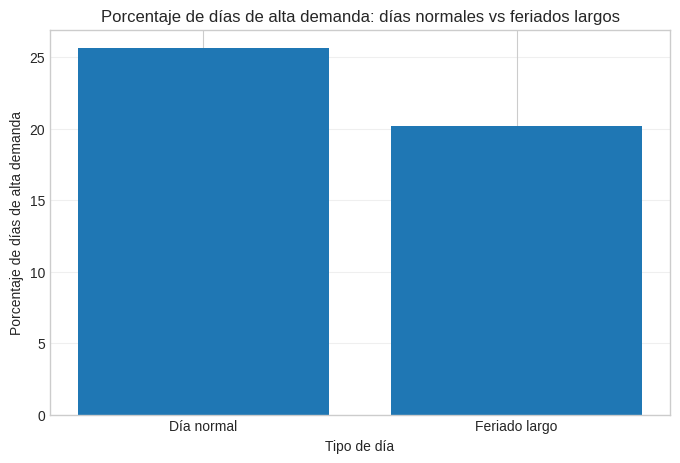

In [79]:
plt.figure(figsize=(8, 5))

plt.bar(
    alta_demanda_feriados['tipo_dia'],
    alta_demanda_feriados['porcentaje_alta_demanda']
)

plt.title('Porcentaje de días de alta demanda: días normales vs feriados largos')
plt.xlabel('Tipo de día')
plt.ylabel('Porcentaje de días de alta demanda')
plt.grid(axis='y', alpha=0.3)

plt.show()

Se definió como día de alta demanda a aquellos días que se encuentran dentro del 25% con mayor cantidad de pasajeros. Esta clasificación permite transformar el análisis predictivo en una herramienta de alerta para la empresa. Si un día futuro presenta características similares a los días de alta demanda, la empresa podría anticipar refuerzos en personal, transporte, atención al pasajero y coordinación operativa.

## Ejemplos de escenarios

In [80]:
# Simulación de escenarios futuros con el modelo de calendario

escenarios = pd.DataFrame({
    'mes': [1, 7, 7, 10, 12],
    'dia_semana_num': [2, 5, 6, 5, 4],
    'es_fin_de_semana': [0, 1, 1, 1, 0],
    'es_feriado_largo': [0, 0, 1, 1, 1]
})

escenarios['descripcion'] = [
    'Día normal de enero',
    'Sábado de julio',
    'Domingo de julio en feriado largo',
    'Sábado de octubre en feriado largo',
    'Viernes de diciembre en feriado largo'
]

# Reordenamos columnas para predecir
X_escenarios = escenarios[
    [
        'mes',
        'dia_semana_num',
        'es_fin_de_semana',
        'es_feriado_largo'
    ]
]

escenarios['pasajeros_estimados'] = modelo_calendario.predict(X_escenarios)

display(escenarios[['descripcion', 'pasajeros_estimados']])

,descripcion,pasajeros_estimados
0,Día normal de enero,3448.561820
1,Sábado de julio,6209.400705
2,Domingo de julio en feriado largo,4469.292976
3,Sábado de octubre en feriado largo,3920.174722
4,Viernes de diciembre en feriado largo,3460.104338


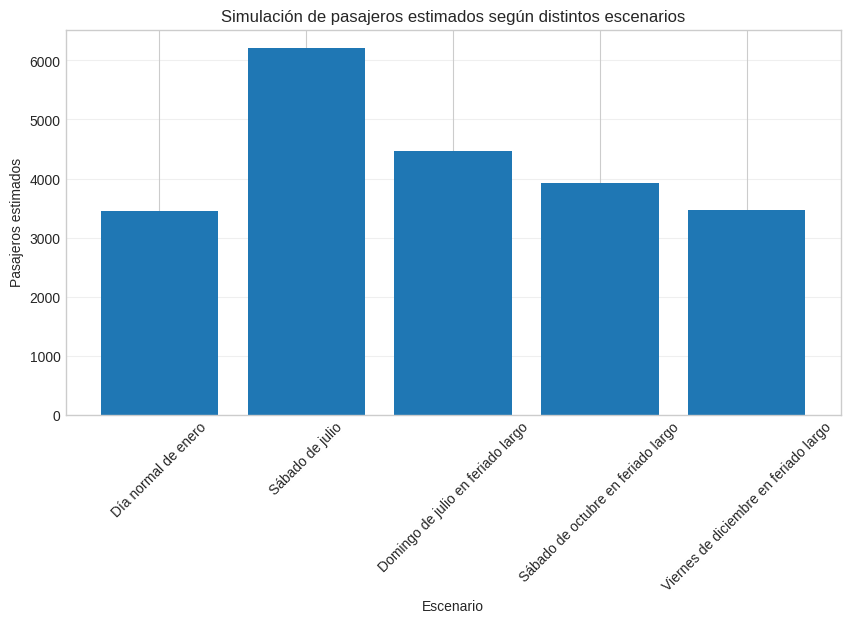

In [81]:
plt.figure(figsize=(10, 5))

plt.bar(
    escenarios['descripcion'],
    escenarios['pasajeros_estimados']
)

plt.title('Simulación de pasajeros estimados según distintos escenarios')
plt.xlabel('Escenario')
plt.ylabel('Pasajeros estimados')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

A partir de los modelos predictivos desarrollados, se observa que la demanda aérea hacia Bariloche está fuertemente influenciada por la estacionalidad mensual. Esto significa que la empresa debe prestar especial atención a los meses de mayor movimiento turístico, principalmente aquellos vinculados con temporada alta.

Si bien los feriados largos no aparecen como la variable más influyente del modelo, siguen siendo relevantes para la planificación operativa, ya que pueden coincidir con períodos de alta demanda. Por este motivo, se recomienda utilizar el modelo como una herramienta de alerta temprana para anticipar días críticos.

La empresa podría aplicar este tipo de predicción para reforzar personal, mejorar la atención al pasajero, coordinar mejor los servicios de transporte y anticipar posibles saturaciones durante fechas turísticas clave.

## Limitaciones del modelo predictivo

Si bien los modelos desarrollados permiten estimar la demanda diaria de pasajeros en Bariloche, deben interpretarse como una herramienta de apoyo para la toma de decisiones y no como una predicción exacta.

Una limitación importante es que el modelo utiliza principalmente variables de calendario, como mes, día de la semana, fin de semana y feriado largo. Sin embargo, la demanda aérea también puede verse afectada por otros factores que no están incluidos en el dataset, como condiciones climáticas, precios de pasajes, cancelaciones, promociones turísticas, eventos especiales, capacidad de alojamiento y decisiones operativas de las aerolíneas.

Además, en el primer modelo la variable cantidad de vuelos tiene una influencia muy alta, lo cual es lógico porque a mayor cantidad de vuelos suele haber mayor cantidad de pasajeros. Por eso también se construyó un modelo alternativo sin esa variable, para observar mejor el efecto de la estacionalidad y de los feriados largos.



## Recomendaciones


A partir de los resultados obtenidos en los modelos predictivos, se recomienda que la empresa utilice la estacionalidad mensual como principal criterio de planificación, ya que el mes fue la variable con mayor importancia para estimar la cantidad diaria de pasajeros que arriban a Bariloche.

Esto indica que la empresa debería anticipar sus recursos principalmente en los meses de mayor demanda turística, especialmente durante la temporada alta. En estos períodos se recomienda reforzar el personal operativo, mejorar la coordinación con los servicios de transporte y prever una mayor demanda en la atención al pasajero.

Si bien los feriados largos no fueron la variable más influyente del modelo, deben ser considerados como fechas de posible refuerzo operativo, ya que pueden coincidir con períodos de alta demanda. Por este motivo, se recomienda incluirlos dentro de una planificación más amplia basada en la temporada del año.

Además, la empresa podría utilizar el modelo predictivo como una herramienta de alerta temprana. Si el modelo estima una cantidad elevada de pasajeros para una fecha determinada, se podrían tomar medidas preventivas, como aumentar la disponibilidad de transporte, reforzar turnos de trabajo, mejorar la comunicación con los pasajeros y coordinar con aerolíneas y prestadores turísticos.

En conclusión, la principal recomendación es no planificar únicamente en función de los feriados largos, sino combinar esa información con la estacionalidad mensual y los datos históricos de pasajeros para anticipar momentos críticos y mejorar la experiencia de quienes llegan a Bariloche.

# Conclusiones del caso Bariloche

El análisis de los datos de aterrizajes y despegues de la ANAC correspondientes al período 2023–2025 demuestra que el aeropuerto de Bariloche presenta una fuerte estacionalidad asociada al turismo. Si bien el promedio diario de pasajeros ronda los **6.800 pasajeros**, la demanda varía significativamente a lo largo del año, alcanzando sus **máximos durante la temporada invernal**.

Los meses de **julio y agosto** concentran la mayor actividad, siendo agosto el mes con el promedio diario más elevado, cercano a los **10.000** pasajeros por día. Esta situación implica un incremento importante en la utilización de la infraestructura aeroportuaria y en la demanda de servicios asociados al transporte turístico.

Las medidas estadísticas muestran una dispersión considerable de los datos (desvío estándar cercano a 2.000 pasajeros diarios), lo que indica que la afluencia de viajeros puede fluctuar notablemente entre distintos días y temporadas. Además, el análisis horario evidencia una mayor concentración de pasajeros durante el invierno, especialmente en las franjas centrales del día.

La distribución semanal revela que los **sábados** son los días de mayor movimiento de pasajeros durante agosto, información relevante para la planificación operativa de aerolíneas, aeropuerto, transporte terrestre y servicios turísticos.

Finalmente, los modelos probabilísticos aplicados permitieron cuantificar distintos escenarios de alta demanda durante la temporada invernal. Por un lado, el modelo binomial estimó una probabilidad cercana al 46% de que, en un conjunto de diez movimientos seleccionados al azar, al menos tres correspondan a operaciones de muy alta demanda. Por otro lado, el modelo de Poisson indicó una probabilidad aproximada del 21% de que un día cualquiera de la temporada invernal registre más de diez movimientos de muy alta demanda. Estos resultados evidencian que los períodos de elevada concentración de pasajeros constituyen una situación relativamente frecuente en el aeropuerto de Bariloche durante los meses de invierno.

En conjunto, los resultados confirman que Bariloche es uno de los principales polos receptores de pasajeros del país y que la planificación de recursos, infraestructura y servicios debe contemplar especialmente los períodos de temporada alta, donde la demanda puede superar ampliamente los niveles promedio anuales.

# Conclusiones generales

a

# Limitaciones generales

Los resultados deben interpretarse considerando las siguientes limitaciones:

- **Diferencias entre fuentes:** los datasets de conectividad, ANAC y Failbondi tienen distintos períodos, estructuras y niveles de agregación, por lo que no siempre permiten comparaciones directas.

- **Períodos incompletos:** los datos de 2026 de ANAC están disponibles únicamente hasta abril. Por este motivo, no se utilizan para comparaciones anuales completas.

- **Representatividad de las demoras:** Failbondi puede no incluir la totalidad de los vuelos operados en Argentina y depende de su propia metodología de recopilación.

- **Tratamiento de valores extremos:** para analizar las demoras se conservaron valores entre -180 y 360 minutos. Esta decisión evita que casos aislados distorsionen los resultados, pero excluye operaciones extremas que podrían ser reales.

- **Valores imputados:** algunos registros sin información de ocupación fueron completados utilizando la media de su clasificación. Aunque representan una proporción pequeña, son valores estimados.

- **Pasajeros y movimientos:** en algunos análisis de Bariloche se consideran conjuntamente aterrizajes y despegues. En esos casos, los resultados representan movimientos de pasajeros registrados y no personas únicas que llegan a la ciudad.

- **Variables externas:** no se incorporaron factores como clima, precios de pasajes, cancelaciones, promociones turísticas, eventos, capacidad hotelera o decisiones operativas de las aerolíneas.


# Bibliografía
- Administración Nacional de Aviación Civil. (s. f.). Aterrizajes y despegues procesados por la Administración Nacional de Aviación Civil (ANAC) [Conjunto de datos]. Datos Argentina. Recuperado el 20 de mayo de 2026, de https://datos.gob.ar/dataset/transporte-aterrizajes-despegues-procesados-por-administracion-nacional-aviacion-civil-anac
- Datos Argentina. (s. f.). Datos Argentina: Portal nacional de datos públicos. Recuperado el 20 de mayo de 2026, de https://www.datos.gob.ar/

- Failbondi. (s. f.). Acerca de Failbondi. Recuperado el 20 de mayo de 2026, de https://failbondi.fail/acerca

- Tableros Yvera. (s. f.). Conectividad aérea. Recuperado el 20 de mayo de 2026, de https://tableros.yvera.tur.ar/conectividad/

- Material de clase de Matemática IV e Introducción a Ciencia de Datos. (2026). 

- Martin-Rodriguez, G., & Caceres-Hernandez, J. J. (2023). Seasonal variations in daily data: An application to air passenger arrivals. Journal of Air Transport Management, 110, Article 102419. https://doi.org/10.1016/j.jairtraman.2023.102419

- Chudy-Laskowska, K., & Pisula, T. (2017). Seasonal forecasting for air passenger traffic. En 4th International Multidisciplinary Scientific Conference on Social Sciences & Arts SGEM 2017 (pp. 681–692). https://doi.org/10.5593/sgemsocial2017/14/S04.089

- Serrano Ortega, A., Ruiz Martín, A., & Argerich Martín, C. (2026). Air traffic demand forecasting for origin–destination airport pairs using artificial intelligence. Engineering Proceedings, 133(1), Article 25. https://doi.org/10.3390/engproc2026133025

- Blasco-Puyuelo, J., Burrieza-Galán, J., Cantú-Ros, O. G., Herranz, R., & Mocholí, D. (2023). A machine learning approach for predicting airport passenger flows. En Proceedings of the 2023 SESAR Innovation Days. https://doi.org/10.61009/SID.2023.1.37


El repositorio con los dataset se encuentra en: https://github.com/mletelle/MateIV_Transporte_Publico/ 